In [1]:
# =============================================================================
#  MARKETPLACE360 COLOMBIA — CLASE 1
#  Analítica Descriptiva | Calidad de Datos | Exploración
#  Semana 11 · Analítica Predictiva – Marketing
# =============================================================================
#
#  ESTRUCTURA DEL SCRIPT:
#  Bloque 00 │ Instalación y carga de librerías
#  Bloque 01 │ Simulación del dataset (con NA y outliers)
#  Bloque 02 │ Inspección inicial del dataset
#  Bloque 03 │ Análisis de valores faltantes
#  Bloque 04 │ Análisis de valores atípicos
#  Bloque 05 │ Limpieza y tratamiento de datos
#  Bloque 06 │ Estadísticos descriptivos globales
#  Bloque 07 │ Análisis descriptivo por canal (App vs Web)
#  Bloque 08 │ Análisis descriptivo por ciudad
#  Bloque 09 │ Análisis de variables categóricas
#  Bloque 10 │ Visualizaciones integradas
#  Bloque 11 │ Tabla resumen ejecutivo
# =============================================================================

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
#  BLOQUE 00 · LIBRERÍAS
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Estética global
plt.rcParams.update({
    "figure.facecolor": "#F8F9FA",
    "axes.facecolor":   "#F8F9FA",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
    "axes.labelsize":   11,
})

AZUL    = "#1A5294"
VERDE   = "#1E824C"
NARANJA = "#D35400"
ROJO    = "#B0171F"
MORADO  = "#76448A"
GRIS    = "#7F8C8D"

print("✅ Librerías cargadas correctamente.")

✅ Librerías cargadas correctamente.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  BLOQUE 01 · SIMULACIÓN DEL DATASET
#  1 800 transacciones · 12 variables · Semilla fija para reproducibilidad
# ─────────────────────────────────────────────────────────────────────────────
np.random.seed(2025)
N = 1800

# ── 1.1 Variables base ───────────────────────────────────────────────────────
canal    = np.random.choice(["App", "Web"], size=N, p=[0.55, 0.45])
ciudades = ["Bogotá", "Medellín", "Cali", "Barranquilla"]
ciudad   = np.random.choice(ciudades, size=N, p=[0.40, 0.28, 0.20, 0.12])

categorias = ["Tecnología", "Moda", "Hogar", "Deportes"]
categoria  = np.random.choice(categorias, size=N, p=[0.30, 0.30, 0.22, 0.18])

# ── 1.2 Ticket de compra (COP miles) ─────────────────────────────────────────
#  App: media $185k  SD $60k  (campaña UX → tickets más altos y consistentes)
#  Web: media $162k  SD $75k  (mayor variabilidad, sin intervención)
ticket = np.where(
    canal == "App",
    np.random.normal(185, 60, N),
    np.random.normal(162, 75, N)
)
ticket = np.round(np.clip(ticket, 20, 600), 1)

# ── 1.3 Valores ATÍPICOS en ticket (5 % de las filas) ───────────────────────
idx_outlier_ticket = np.random.choice(N, size=int(N * 0.05), replace=False)
ticket[idx_outlier_ticket] = np.random.choice(
    [5, 8, 10, 750, 900, 1200, 1500],
    size=len(idx_outlier_ticket)
)

# ── 1.4 Tiempo de sesión en minutos ─────────────────────────────────────────
#  App: log-normal  → comportamiento rápido (media ≈18 min)
#  Web: log-normal  → sesiones más largas   (media ≈25 min)
tiempo_sesion = np.where(
    canal == "App",
    np.random.lognormal(mean=np.log(18), sigma=0.55, size=N),
    np.random.lognormal(mean=np.log(25), sigma=0.70, size=N)
)
tiempo_sesion = np.round(np.clip(tiempo_sesion, 1, 120), 1)

# ── 1.5 NPS (Net Promoter Score: -100 a 100) ────────────────────────────────
#  Bogotá y Medellín tienen NPS más alto (usuarios más satisfechos)
nps_base = {
    "Bogotá":       np.random.normal(42, 22, N),
    "Medellín":     np.random.normal(48, 18, N),
    "Cali":         np.random.normal(35, 25, N),
    "Barranquilla": np.random.normal(30, 28, N),
}
nps = np.array([
    nps_base[c][i] for i, c in enumerate(ciudad)
])
nps = np.round(np.clip(nps, -100, 100), 0).astype(float)

# ── 1.6 Conversión (1=compra completada, 0=abandono) ────────────────────────
#  App: tasa de conversión 72 % (campaña UX)
#  Web: tasa de conversión 61 %
conversion = np.where(
    canal == "App",
    np.random.binomial(1, 0.72, N),
    np.random.binomial(1, 0.61, N)
)

# ── 1.7 Número de ítems por carrito ─────────────────────────────────────────
n_items = np.random.poisson(lam=2.8, size=N)
n_items = np.clip(n_items, 1, 15).astype(int)

# ── 1.8 Descuento aplicado (%) ───────────────────────────────────────────────
descuento = np.round(np.random.beta(a=2, b=5, size=N) * 60, 1)

# ── 1.9 Método de pago ───────────────────────────────────────────────────────
metodos = ["Tarjeta crédito", "PSE", "Efecty", "Nequi", "Daviplata"]
metodo_pago = np.random.choice(metodos, N, p=[0.38, 0.25, 0.12, 0.15, 0.10])

# ── 1.10 Mes de la transacción (ene–jun 2025) ────────────────────────────────
mes = np.random.choice(range(1, 7), N, p=[0.14, 0.15, 0.18, 0.17, 0.19, 0.17])

# ── 1.11 Construcción del DataFrame ─────────────────────────────────────────
df_raw = pd.DataFrame({
    "id_transaccion": range(1, N + 1),
    "canal":          canal,
    "ciudad":         ciudad,
    "categoria":      categoria,
    "ticket_cop_k":   ticket,          # en miles de COP
    "tiempo_sesion_min": tiempo_sesion,
    "nps":            nps,
    "conversion":     conversion,
    "n_items":        n_items,
    "descuento_pct":  descuento,
    "metodo_pago":    metodo_pago,
    "mes":            mes,
})

# ── 1.12 Inyección de VALORES FALTANTES (MCAR y MAR) ────────────────────────
#  — ticket_cop_k:     5 % aleatorio (MCAR)
#  — nps:             8 % en Barranquilla (MAR: menos respuestas en esa ciudad)
#  — tiempo_sesion:   4 % aleatorio (MCAR)
#  — metodo_pago:     3 % aleatorio (MCAR)

idx_na_ticket = np.random.choice(N, int(N * 0.05), replace=False)
df_raw.loc[idx_na_ticket, "ticket_cop_k"] = np.nan

idx_baq  = df_raw[df_raw["ciudad"] == "Barranquilla"].index.tolist()
idx_na_nps = np.random.choice(idx_baq, int(len(idx_baq) * 0.08), replace=False)
df_raw.loc[idx_na_nps, "nps"] = np.nan

idx_na_ts = np.random.choice(N, int(N * 0.04), replace=False)
df_raw.loc[idx_na_ts, "tiempo_sesion_min"] = np.nan

idx_na_mp = np.random.choice(N, int(N * 0.03), replace=False)
df_raw.loc[idx_na_mp, "metodo_pago"] = np.nan

print(f"✅ Dataset simulado: {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas")
print(f"   Tasa de conversión App: {df_raw[df_raw.canal=='App']['conversion'].mean():.1%}")
print(f"   Tasa de conversión Web: {df_raw[df_raw.canal=='Web']['conversion'].mean():.1%}")



✅ Dataset simulado: 1800 filas × 12 columnas
   Tasa de conversión App: 72.1%
   Tasa de conversión Web: 60.5%


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
#  BLOQUE 02 · INSPECCIÓN INICIAL
# ─────────────────────────────────────────────────────────────────────────────
SEP = "=" * 65

print(f"\n{SEP}")
print("  BLOQUE 02 — INSPECCIÓN INICIAL DEL DATASET")
print(SEP)

print("\n► Primeras 8 observaciones:")
print(df_raw.head(8).to_string(index=False))

print("\n► Tipos de datos y conteo de no-nulos:")
df_raw.info()

print("\n► Estadísticos descriptivos básicos (variables numéricas):")
print(df_raw.describe().round(2).to_string())


  BLOQUE 02 — INSPECCIÓN INICIAL DEL DATASET

► Primeras 8 observaciones:
 id_transaccion canal   ciudad  categoria  ticket_cop_k  tiempo_sesion_min  nps  conversion  n_items  descuento_pct     metodo_pago  mes
              1   App   Bogotá Tecnología         170.8                NaN 48.0           1        3           28.3           Nequi    5
              2   Web   Bogotá       Moda         226.1               19.8 18.0           1        1           20.8 Tarjeta crédito    1
              3   Web   Bogotá       Moda         314.8               39.3 74.0           1        3           13.6             PSE    4
              4   App Medellín      Hogar         126.8               74.6 21.0           0        5            6.7             PSE    1
              5   App Medellín Tecnología          92.3               18.4 64.0           0        2           29.7             PSE    4
              6   App   Bogotá   Deportes          46.3                7.4 41.0           0        2   


  BLOQUE 03 — ANÁLISIS DE VALORES FALTANTES

► Resumen de valores faltantes:
         Variable  N_faltantes  Pct_faltantes Tipo_NA
     ticket_cop_k           90           5.00    MCAR
tiempo_sesion_min           72           4.00    MCAR
              nps           16           0.89     MAR
      metodo_pago           54           3.00    MCAR

  Total celdas faltantes: 232
  % filas con al menos 1 NA: 12.2 %


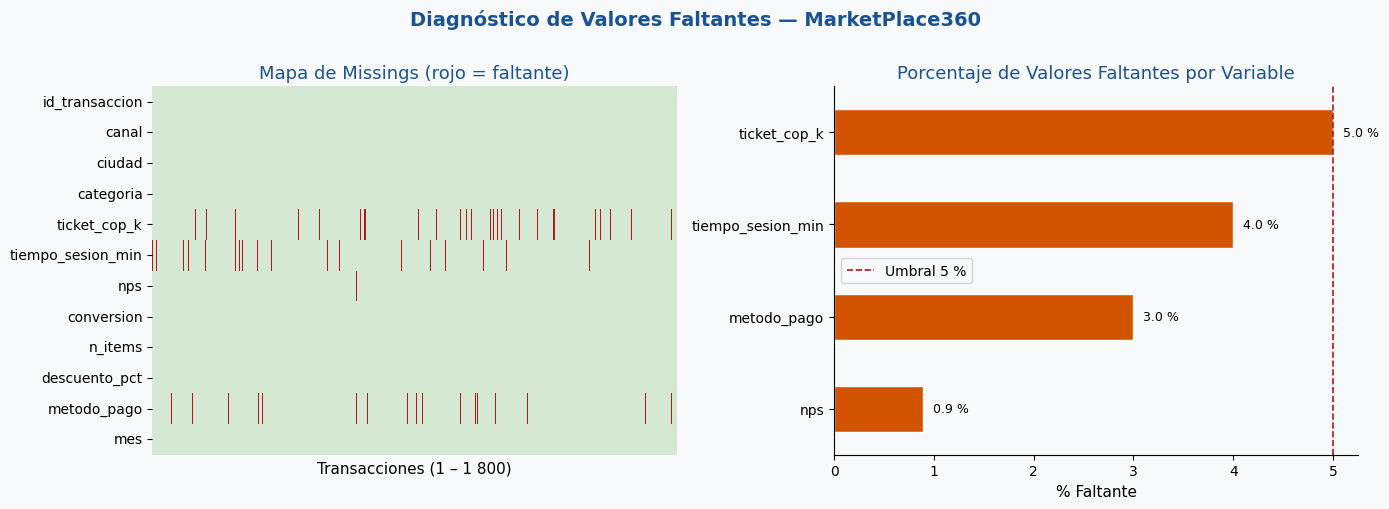

✅ Figura 1 guardada: fig01_missings.png


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
#  BLOQUE 03 · ANÁLISIS DE VALORES FALTANTES
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{SEP}")
print("  BLOQUE 03 — ANÁLISIS DE VALORES FALTANTES")
print(SEP)

# ── 3.1 Tabla de missings ────────────────────────────────────────────────────
missing = pd.DataFrame({
    "Variable":      df_raw.columns,
    "N_faltantes":   df_raw.isna().sum().values,
    "Pct_faltantes": (df_raw.isna().mean() * 100).round(2).values,
    "Tipo_NA":       ["–","–","–","–","MCAR","MCAR","MAR","–","–","–","MCAR","–"],
}).query("N_faltantes > 0").reset_index(drop=True)

print("\n► Resumen de valores faltantes:")
print(missing.to_string(index=False))
print(f"\n  Total celdas faltantes: {df_raw.isna().sum().sum()}")
print(f"  % filas con al menos 1 NA: "
      f"{(df_raw.isna().any(axis=1).mean()*100):.1f} %")

# ── 3.2 Heatmap de missings ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Diagnóstico de Valores Faltantes — MarketPlace360",
             fontsize=14, fontweight="bold", color=AZUL, y=1.01)

# Panel izquierdo: heatmap
sns.heatmap(
    df_raw.isna().astype(int).T,
    cmap=["#D5E8D4","#B0171F"],
    cbar=False,
    yticklabels=df_raw.columns,
    xticklabels=False,
    ax=axes[0],
    linewidths=0
)
axes[0].set_title("Mapa de Missings (rojo = faltante)", color=AZUL)
axes[0].set_xlabel("Transacciones (1 – 1 800)")
axes[0].set_ylabel("")

# Panel derecho: barras de porcentaje
missing_all = (df_raw.isna().mean() * 100).sort_values(ascending=True)
missing_all = missing_all[missing_all > 0]
colors_bar  = [ROJO if v > 5 else NARANJA for v in missing_all.values]
missing_all.plot(kind="barh", ax=axes[1], color=colors_bar, edgecolor="white")
axes[1].set_title("Porcentaje de Valores Faltantes por Variable", color=AZUL)
axes[1].set_xlabel("% Faltante")
axes[1].axvline(5, color=ROJO, ls="--", lw=1.2, label="Umbral 5 %")
for i, v in enumerate(missing_all.values):
    axes[1].text(v + 0.1, i, f"{v:.1f} %", va="center", fontsize=9)
axes[1].legend()

plt.tight_layout()
#plt.savefig("fig01_missings.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figura 1 guardada: fig01_missings.png")

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
#  BLOQUE 04 · ANÁLISIS DE VALORES ATÍPICOS
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{SEP}")
print("  BLOQUE 04 — ANÁLISIS DE VALORES ATÍPICOS")
print(SEP)

vars_numericas = ["ticket_cop_k", "tiempo_sesion_min", "nps"]

# ── 4.1 Método IQR ──────────────────────────────────────────────────────────
def diagnostico_outliers_iqr(series, nombre):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr    = q3 - q1
    li, ls = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    out    = series[(series < li) | (series > ls)]
    print(f"\n  Variable: {nombre}")
    print(f"    Q1={q1:.2f}  Q3={q3:.2f}  IQR={iqr:.2f}")
    print(f"    Límite inferior: {li:.2f}  │  Límite superior: {ls:.2f}")
    print(f"    Outliers detectados: {len(out)}  ({len(out)/len(series)*100:.1f} %)")
    print(f"    Rango outliers: [{out.min():.1f},  {out.max():.1f}]")
    return li, ls, out

print("\n► Método IQR (Tukey):")
limites = {}
for v in vars_numericas:
    li, ls, out = diagnostico_outliers_iqr(df_raw[v].dropna(), v)
    limites[v] = (li, ls)


  BLOQUE 04 — ANÁLISIS DE VALORES ATÍPICOS

► Método IQR (Tukey):

  Variable: ticket_cop_k
    Q1=124.98  Q3=223.05  IQR=98.08
    Límite inferior: -22.14  │  Límite superior: 370.16
    Outliers detectados: 47  (2.7 %)
    Rango outliers: [389.4,  1500.0]

  Variable: tiempo_sesion_min
    Q1=13.40  Q3=31.52  IQR=18.12
    Límite inferior: -13.79  │  Límite superior: 58.71
    Outliers detectados: 92  (5.3 %)
    Rango outliers: [58.9,  120.0]

  Variable: nps
    Q1=26.00  Q3=57.00  IQR=31.00
    Límite inferior: -20.50  │  Límite superior: 103.50
    Outliers detectados: 8  (0.4 %)
    Rango outliers: [-45.0,  -21.0]


In [8]:
# ── 4.2 Método Z-score ──────────────────────────────────────────────────────
print("\n► Método Z-score (|z| > 3):")
for v in vars_numericas:
    s    = df_raw[v].dropna()
    z    = np.abs(stats.zscore(s))
    n_z  = (z > 3).sum()
    print(f"  {v}: {n_z} outliers ({n_z/len(s)*100:.1f} %)")



► Método Z-score (|z| > 3):
  ticket_cop_k: 45 outliers (2.6 %)
  tiempo_sesion_min: 38 outliers (2.2 %)
  nps: 4 outliers (0.2 %)


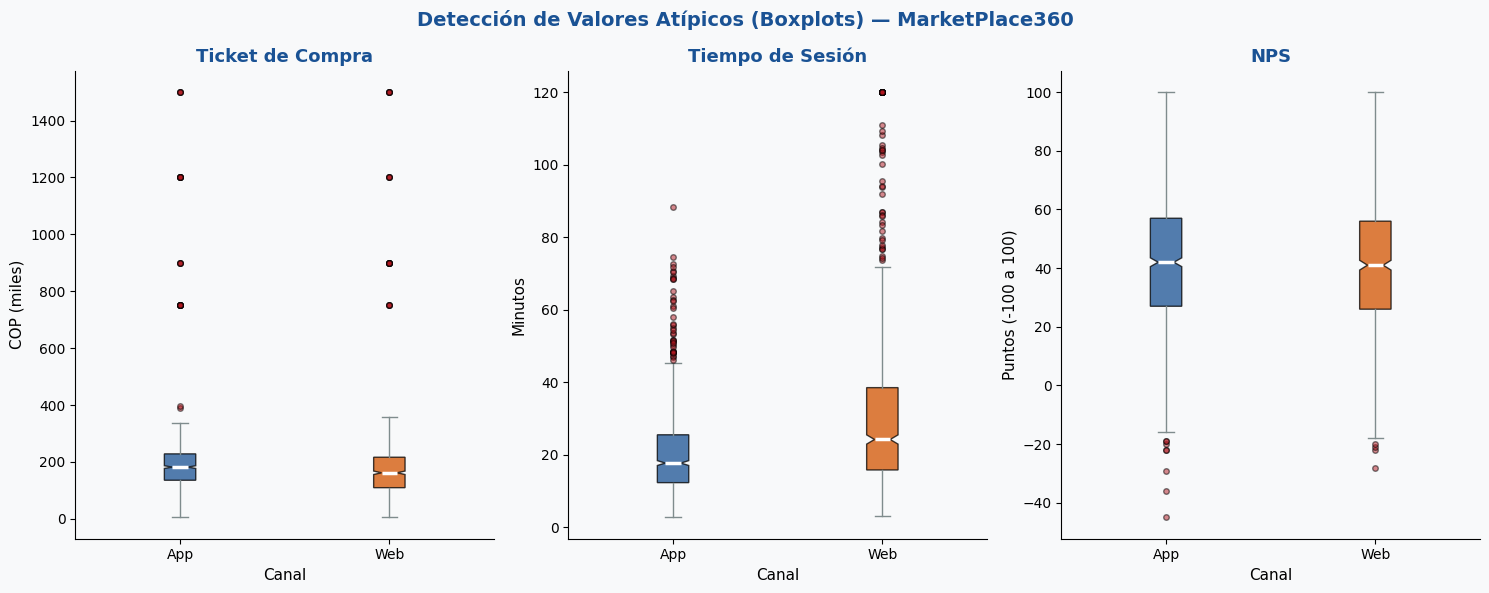

✅ Figura 2 guardada: fig02_outliers_boxplot.png


In [9]:
# ── 4.3 Boxplots comparativos ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle("Detección de Valores Atípicos (Boxplots) — MarketPlace360",
             fontsize=14, fontweight="bold", color=AZUL)

colores_canal = {"App": AZUL, "Web": NARANJA}
for ax, var, titulo, unidad in zip(
    axes,
    ["ticket_cop_k", "tiempo_sesion_min", "nps"],
    ["Ticket de Compra", "Tiempo de Sesión", "NPS"],
    ["COP (miles)", "Minutos", "Puntos (-100 a 100)"]
):
    data_plot = [
        df_raw.loc[df_raw.canal == c, var].dropna().values
        for c in ["App", "Web"]
    ]
    bp = ax.boxplot(
        data_plot, labels=["App", "Web"],
        patch_artist=True, notch=True,
        medianprops=dict(color="white", linewidth=2.5),
        whiskerprops=dict(color=GRIS),
        capprops=dict(color=GRIS),
        flierprops=dict(marker="o", markerfacecolor=ROJO,
                        markersize=4, alpha=0.5)
    )
    for patch, color in zip(bp["boxes"], [AZUL, NARANJA]):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_title(titulo, color=AZUL, fontweight="bold")
    ax.set_ylabel(unidad)
    ax.set_xlabel("Canal")

plt.tight_layout()
#plt.savefig("fig02_outliers_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figura 2 guardada: fig02_outliers_boxplot.png")

In [10]:

# ─────────────────────────────────────────────────────────────────────────────
#  BLOQUE 05 · LIMPIEZA Y TRATAMIENTO DE DATOS
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{SEP}")
print("  BLOQUE 05 — LIMPIEZA Y TRATAMIENTO")
print(SEP)

df = df_raw.copy()

# ── 5.1 Tratamiento de outliers en ticket ───────────────────────────────────
#  Decisión: Winsorización al 1 % y 99 % (conservamos todas las filas)
#  Justificación: los extremos podrían ser compras válidas pero distorsionan
#  los estimadores. La winsorización es preferible a la eliminación en
#  datasets de transacciones de e-commerce.

p01 = df["ticket_cop_k"].quantile(0.01)
p99 = df["ticket_cop_k"].quantile(0.99)
df["ticket_cop_k"] = df["ticket_cop_k"].clip(lower=p01, upper=p99)
print(f"\n► Winsorización de ticket_cop_k:")
print(f"   P1  = {p01:.1f}  →  límite inferior")
print(f"   P99 = {p99:.1f}  →  límite superior")
print(f"   Filas modificadas: {((df_raw['ticket_cop_k'] < p01) | (df_raw['ticket_cop_k'] > p99)).sum()}")

# ── 5.2 Imputación de valores faltantes ─────────────────────────────────────
#  ticket_cop_k:        imputación por mediana del canal (MAR condicional)
#  tiempo_sesion_min:   imputación por mediana del canal
#  nps:                 imputación por mediana de la ciudad
#  metodo_pago:         imputación por moda global

for canal_val in ["App", "Web"]:
    mask = (df["canal"] == canal_val) & df["ticket_cop_k"].isna()
    med  = df.loc[df["canal"] == canal_val, "ticket_cop_k"].median()
    df.loc[mask, "ticket_cop_k"] = med
    print(f"\n► Imputo ticket ({canal_val}) con mediana = {med:.1f}")

for canal_val in ["App", "Web"]:
    mask = (df["canal"] == canal_val) & df["tiempo_sesion_min"].isna()
    med  = df.loc[df["canal"] == canal_val, "tiempo_sesion_min"].median()
    df.loc[mask, "tiempo_sesion_min"] = med
    print(f"► Imputo tiempo_sesion ({canal_val}) con mediana = {med:.1f}")

for c in ciudades:
    mask = (df["ciudad"] == c) & df["nps"].isna()
    med  = df.loc[df["ciudad"] == c, "nps"].median()
    df.loc[mask, "nps"] = med
    print(f"► Imputo NPS ({c}) con mediana = {med:.0f}")

moda_pago = df["metodo_pago"].mode()[0]
df["metodo_pago"] = df["metodo_pago"].fillna(moda_pago)
print(f"► Imputo metodo_pago con moda = '{moda_pago}'")

# ── 5.3 Verificación post-limpieza ──────────────────────────────────────────
nas_post = df.isna().sum().sum()
print(f"\n► Valores faltantes DESPUÉS de limpieza: {nas_post}")
print(f"   Dataset limpio: {df.shape[0]} filas × {df.shape[1]} columnas")


  BLOQUE 05 — LIMPIEZA Y TRATAMIENTO

► Winsorización de ticket_cop_k:
   P1  = 8.0  →  límite inferior
   P99 = 1200.0  →  límite superior
   Filas modificadas: 22

► Imputo ticket (App) con mediana = 182.0

► Imputo ticket (Web) con mediana = 162.0
► Imputo tiempo_sesion (App) con mediana = 17.7
► Imputo tiempo_sesion (Web) con mediana = 24.2
► Imputo NPS (Bogotá) con mediana = 40
► Imputo NPS (Medellín) con mediana = 48
► Imputo NPS (Cali) con mediana = 40
► Imputo NPS (Barranquilla) con mediana = 32
► Imputo metodo_pago con moda = 'Tarjeta crédito'

► Valores faltantes DESPUÉS de limpieza: 0
   Dataset limpio: 1800 filas × 12 columnas


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
#  BLOQUE 06 · ESTADÍSTICOS DESCRIPTIVOS GLOBALES
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{SEP}")
print("  BLOQUE 06 — ESTADÍSTICOS DESCRIPTIVOS GLOBALES")
print(SEP)

def describe_completo(series, nombre):
    """Calcula estadísticos descriptivos completos para una serie."""
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    return {
        "Variable":   nombre,
        "N":          int(series.notna().sum()),
        "Media":      round(series.mean(), 2),
        "Mediana":    round(series.median(), 2),
        "SD":         round(series.std(), 2),
        "CV (%)":     round(series.std() / series.mean() * 100, 1),
        "Mínimo":     round(series.min(), 2),
        "Q1":         round(q1, 2),
        "Q3":         round(q3, 2),
        "Máximo":     round(series.max(), 2),
        "IQR":        round(q3 - q1, 2),
        "Asimetría":  round(stats.skew(series.dropna()), 3),
        "Curtosis":   round(stats.kurtosis(series.dropna()), 3),
    }

tabla_desc = pd.DataFrame([
    describe_completo(df["ticket_cop_k"],      "Ticket (COP k)"),
    describe_completo(df["tiempo_sesion_min"], "Tiempo sesión (min)"),
    describe_completo(df["nps"],               "NPS"),
    describe_completo(df["n_items"],           "N° ítems"),
    describe_completo(df["descuento_pct"],     "Descuento (%)"),
])

print("\n► Tabla de estadísticos descriptivos globales:")
print(tabla_desc.to_string(index=False))


  BLOQUE 06 — ESTADÍSTICOS DESCRIPTIVOS GLOBALES

► Tabla de estadísticos descriptivos globales:
           Variable    N  Media  Mediana     SD  CV (%)  Mínimo     Q1     Q3  Máximo   IQR  Asimetría  Curtosis
     Ticket (COP k) 1800 190.36   175.25 148.27    77.9     8.0 129.38 220.30  1200.0 90.93      4.525    26.048
Tiempo sesión (min) 1800  25.19    20.20  18.40    73.0     2.7  13.60  30.92   120.0 17.32      2.418     7.941
                NPS 1800  41.35    41.50  22.82    55.2   -45.0  27.00  57.00   100.0 30.00     -0.125     0.049
           N° ítems 1800   2.83     3.00   1.58    55.9     1.0   2.00   4.00    10.0  2.00      0.811     0.319
      Descuento (%) 1800  17.06    16.10   9.50    55.7     0.2   9.60  22.80    55.5 13.20      0.601    -0.047


In [12]:
# ── 6.1 Test de normalidad (Shapiro-Wilk sobre muestra de 200) ───────────────
print("\n► Test de normalidad Shapiro-Wilk (n=200):")
for var, nombre in [
    ("ticket_cop_k",      "Ticket"),
    ("tiempo_sesion_min", "Tiempo sesión"),
    ("nps",               "NPS"),
]:
    muestra = df[var].dropna().sample(200, random_state=42)
    stat, p  = stats.shapiro(muestra)
    concl    = "Normal (no rechaza H₀)" if p > 0.05 else "No normal (rechaza H₀)"
    print(f"   {nombre:20s}: W={stat:.4f},  p={p:.4f}  → {concl}")


► Test de normalidad Shapiro-Wilk (n=200):
   Ticket              : W=0.5436,  p=0.0000  → No normal (rechaza H₀)
   Tiempo sesión       : W=0.7226,  p=0.0000  → No normal (rechaza H₀)
   NPS                 : W=0.9931,  p=0.4782  → Normal (no rechaza H₀)


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
#  BLOQUE 07 · ANÁLISIS DESCRIPTIVO POR CANAL (APP vs WEB)
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{SEP}")
print("  BLOQUE 07 — DESCRIPTIVOS POR CANAL (App vs Web)")
print(SEP)

vars_analisis = {
    "ticket_cop_k":      "Ticket (COP k)",
    "tiempo_sesion_min": "Tiempo sesión (min)",
    "nps":               "NPS",
}

for var, nombre in vars_analisis.items():
    print(f"\n  ── {nombre} ──")
    tabla = df.groupby("canal")[var].agg(
        N="count",
        Media="mean",
        Mediana="median",
        SD="std",
        Min="min",
        Max="max",
    ).round(2)
    print(tabla.to_string())

# ── 7.1 Tasas de conversión por canal ───────────────────────────────────────
print("\n► Tasa de conversión por canal:")
conv = df.groupby("canal")["conversion"].agg(
    n_total="count",
    n_compras="sum",
    tasa_conversion=lambda x: x.mean().round(4)
)
conv["tasa_%"] = (conv["tasa_conversion"] * 100).round(2)
print(conv.to_string())


  BLOQUE 07 — DESCRIPTIVOS POR CANAL (App vs Web)

  ── Ticket (COP k) ──
         N   Media  Mediana      SD  Min     Max
canal                                           
App    993  198.15    182.0  143.39  8.0  1200.0
Web    807  180.78    162.0  153.62  8.0  1200.0

  ── Tiempo sesión (min) ──
         N  Media  Mediana     SD  Min    Max
canal                                        
App    993  20.47     17.7  11.84  2.7   88.4
Web    807  31.00     24.2  22.85  3.0  120.0

  ── NPS ──
         N  Media  Mediana     SD   Min    Max
canal                                         
App    993  41.84     42.0  23.10 -45.0  100.0
Web    807  40.74     41.0  22.48 -28.0  100.0

► Tasa de conversión por canal:
       n_total  n_compras  tasa_conversion  tasa_%
canal                                             
App        993        716           0.7210   72.10
Web        807        488           0.6047   60.47


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
#  BLOQUE 08 · ANÁLISIS DESCRIPTIVO POR CIUDAD
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{SEP}")
print("  BLOQUE 08 — DESCRIPTIVOS POR CIUDAD")
print(SEP)

tabla_ciudad = df.groupby("ciudad").agg(
    N                 = ("id_transaccion", "count"),
    Ticket_media      = ("ticket_cop_k",      "mean"),
    Ticket_sd         = ("ticket_cop_k",      "std"),
    Tiempo_media      = ("tiempo_sesion_min", "mean"),
    NPS_media         = ("nps",               "mean"),
    Tasa_conv         = ("conversion",        "mean"),
    Items_media       = ("n_items",           "mean"),
    Descuento_media   = ("descuento_pct",     "mean"),
).round(2)
tabla_ciudad["Tasa_conv_%"] = (tabla_ciudad["Tasa_conv"] * 100).round(1)
print(tabla_ciudad.to_string())



  BLOQUE 08 — DESCRIPTIVOS POR CIUDAD
                N  Ticket_media  Ticket_sd  Tiempo_media  NPS_media  Tasa_conv  Items_media  Descuento_media  Tasa_conv_%
ciudad                                                                                                                   
Barranquilla  208        190.03     125.33         25.69      31.46       0.66         2.84            17.23         66.0
Bogotá        692        196.10     163.25         25.73      40.65       0.67         2.86            16.94         67.0
Cali          363        196.22     142.68         24.64      38.17       0.67         2.79            17.22         67.0
Medellín      537        179.13     139.37         24.67      48.22       0.66         2.82            17.04         66.0


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
#  BLOQUE 09 · ANÁLISIS DE VARIABLES CATEGÓRICAS
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{SEP}")
print("  BLOQUE 09 — VARIABLES CATEGÓRICAS")
print(SEP)

# ── 9.1 Método de pago ─────────────────────────────────────────────────────
print("\n► Distribución de métodos de pago:")
mp = df["metodo_pago"].value_counts(normalize=True).mul(100).round(2)
print(mp.to_string())

# ── 9.2 Categoría de producto ───────────────────────────────────────────────
print("\n► Ticket promedio por categoría:")
print(
    df.groupby("categoria")["ticket_cop_k"]
    .agg(["mean","median","std","count"])
    .round(2)
    .to_string()
)

# ── 9.3 Tabla cruzada canal × conversión ───────────────────────────────────
print("\n► Tabla cruzada Canal × Conversión (frecuencias relativas %):")
ct = pd.crosstab(
    df["canal"], df["conversion"],
    rownames=["Canal"],
    colnames=["Conversión (0=Abandono, 1=Compra)"],
    normalize="index"
).mul(100).round(2)
print(ct.to_string())

# ── 9.4 Ticket promedio por mes ─────────────────────────────────────────────
meses_nombres = {1:"Ene",2:"Feb",3:"Mar",4:"Abr",5:"May",6:"Jun"}
print("\n► Evolución mensual del ticket promedio por canal:")
evol = df.groupby(["mes","canal"])["ticket_cop_k"].mean().unstack().round(2)
evol.index = evol.index.map(meses_nombres)
print(evol.to_string())



  BLOQUE 09 — VARIABLES CATEGÓRICAS

► Distribución de métodos de pago:
metodo_pago
Tarjeta crédito    38.72
PSE                22.11
Nequi              16.11
Efecty             12.56
Daviplata          10.50

► Ticket promedio por categoría:
              mean  median     std  count
categoria                                
Deportes    190.00   178.8  146.98    313
Hogar       192.48   179.4  139.19    401
Moda        190.78   176.5  150.30    567
Tecnología  188.49   168.8  153.92    519

► Tabla cruzada Canal × Conversión (frecuencias relativas %):
Conversión (0=Abandono, 1=Compra)      0      1
Canal                                          
App                                27.90  72.10
Web                                39.53  60.47

► Evolución mensual del ticket promedio por canal:
canal     App     Web
mes                  
Ene    191.74  162.33
Feb    190.58  166.03
Mar    207.57  183.32
Abr    208.60  207.22
May    191.57  174.97
Jun    194.84  183.82


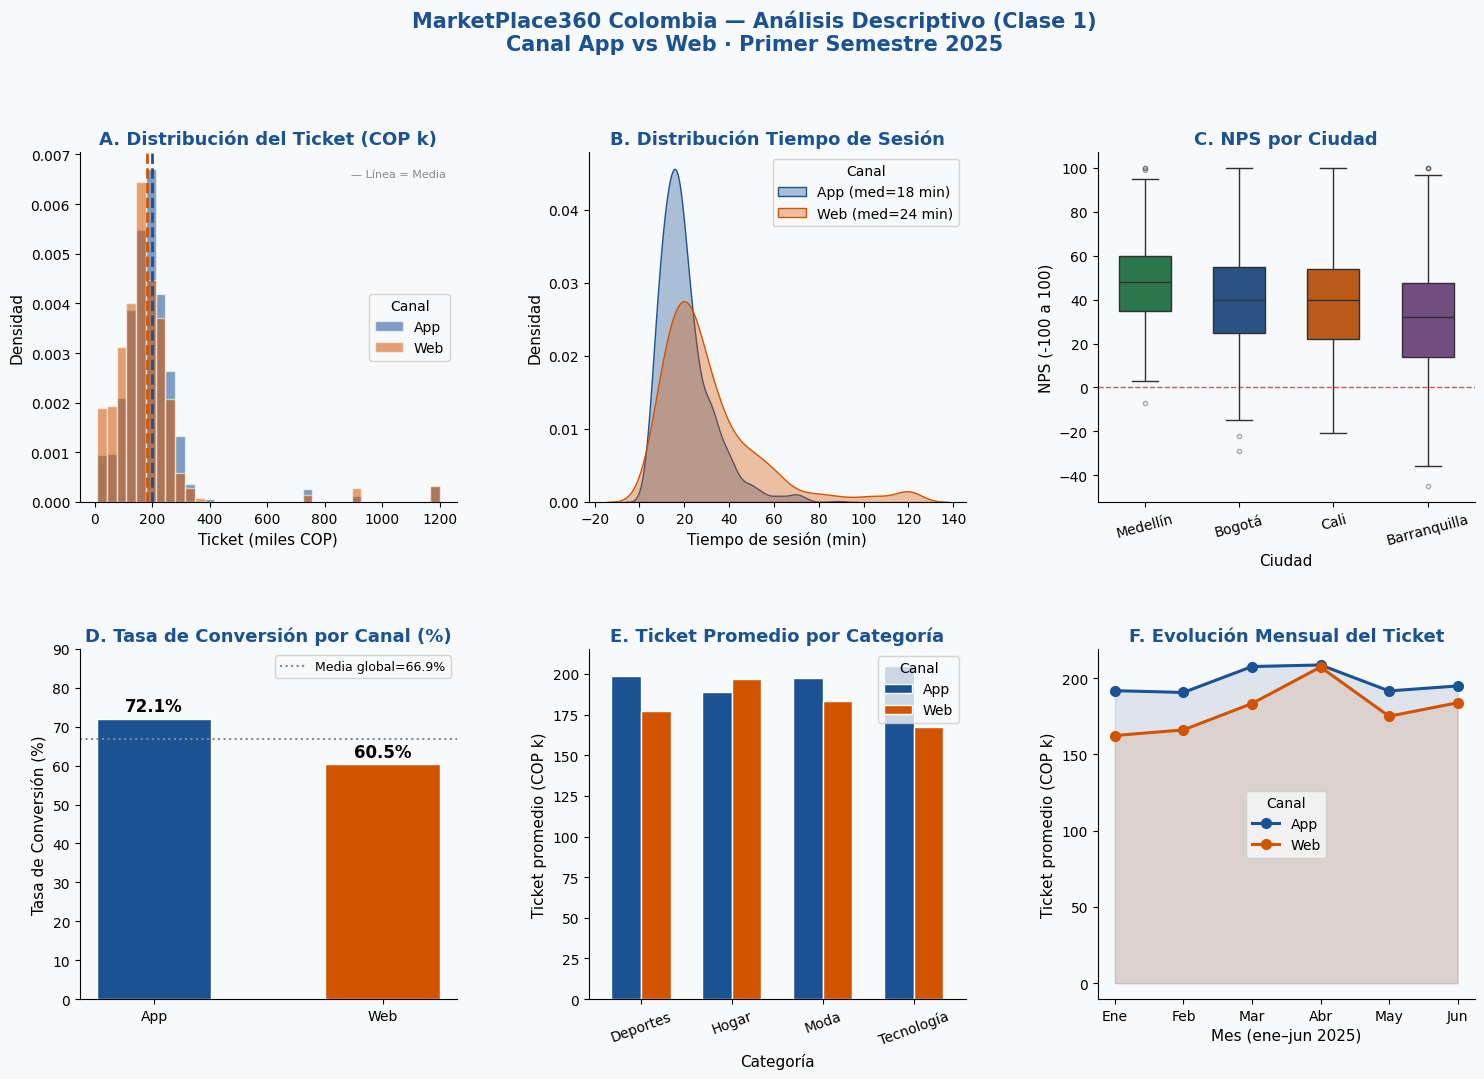

✅ Figura 3 guardada: fig03_panel_descriptivo.png


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
#  BLOQUE 10 · VISUALIZACIONES INTEGRADAS
# ─────────────────────────────────────────────────────────────────────────────

# ────────────────────────────────────────────────────────
#  FIGURA 3: Panel descriptivo principal (2×3)
# ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 11))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)
fig.suptitle(
    "MarketPlace360 Colombia — Análisis Descriptivo (Clase 1)\n"
    "Canal App vs Web · Primer Semestre 2025",
    fontsize=15, fontweight="bold", color=AZUL, y=1.01
)

# ── Panel A: Histogramas superpuestos del ticket ─────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
for canal_val, color in [("App", AZUL), ("Web", NARANJA)]:
    datos = df[df["canal"] == canal_val]["ticket_cop_k"].dropna()
    ax_a.hist(datos, bins=35, alpha=0.55, color=color,
              edgecolor="white", label=canal_val, density=True)
    ax_a.axvline(datos.mean(), color=color, lw=2, ls="--")
ax_a.set_title("A. Distribución del Ticket (COP k)", color=AZUL, fontweight="bold")
ax_a.set_xlabel("Ticket (miles COP)")
ax_a.set_ylabel("Densidad")
ax_a.legend(title="Canal")
ax_a.text(0.97, 0.95, "— Línea = Media", transform=ax_a.transAxes,
          ha="right", va="top", fontsize=8, color=GRIS)

# ── Panel B: KDE tiempo de sesión por canal ──────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
for canal_val, color in [("App", AZUL), ("Web", NARANJA)]:
    datos = df[df["canal"] == canal_val]["tiempo_sesion_min"].dropna()
    sns.kdeplot(datos, ax=ax_b, color=color, fill=True, alpha=0.35,
                label=f"{canal_val} (med={datos.median():.0f} min)")
ax_b.set_title("B. Distribución Tiempo de Sesión", color=AZUL, fontweight="bold")
ax_b.set_xlabel("Tiempo de sesión (min)")
ax_b.set_ylabel("Densidad")
ax_b.legend(title="Canal")

# ── Panel C: Boxplot NPS por ciudad ─────────────────────────────────────────
ax_c = fig.add_subplot(gs[0, 2])
df_sorted = df.copy()
orden_ciudad = df.groupby("ciudad")["nps"].median().sort_values(ascending=False).index
sns.boxplot(
    data=df, x="ciudad", y="nps", order=orden_ciudad,
    palette={"Bogotá": AZUL,"Medellín": VERDE,
             "Cali": NARANJA,"Barranquilla": MORADO},
    ax=ax_c, width=0.55, flierprops=dict(marker="o", ms=3, alpha=0.4)
)
ax_c.set_title("C. NPS por Ciudad", color=AZUL, fontweight="bold")
ax_c.set_xlabel("Ciudad")
ax_c.set_ylabel("NPS (-100 a 100)")
ax_c.axhline(0, color=ROJO, ls="--", lw=1, alpha=0.7, label="NPS=0")
ax_c.tick_params(axis="x", rotation=15)

# ── Panel D: Barras de tasa de conversión por canal ──────────────────────────
ax_d = fig.add_subplot(gs[1, 0])
conv_data = df.groupby("canal")["conversion"].mean() * 100
bars = ax_d.bar(conv_data.index, conv_data.values,
                color=[AZUL, NARANJA], edgecolor="white", width=0.5)
for bar, val in zip(bars, conv_data.values):
    ax_d.text(bar.get_x() + bar.get_width()/2,
              val + 0.8, f"{val:.1f}%",
              ha="center", va="bottom", fontweight="bold", fontsize=12)
ax_d.set_title("D. Tasa de Conversión por Canal (%)", color=AZUL, fontweight="bold")
ax_d.set_ylabel("Tasa de Conversión (%)")
ax_d.set_ylim(0, 90)
ax_d.axhline(df["conversion"].mean()*100, color=GRIS,
             ls=":", lw=1.5, label=f"Media global={df['conversion'].mean()*100:.1f}%")
ax_d.legend(fontsize=9)

# ── Panel E: Ticket promedio por categoría y canal ───────────────────────────
ax_e = fig.add_subplot(gs[1, 1])
pivot_cat = df.groupby(["categoria","canal"])["ticket_cop_k"].mean().unstack()
pivot_cat.plot(kind="bar", ax=ax_e, color=[AZUL, NARANJA],
               edgecolor="white", width=0.65)
ax_e.set_title("E. Ticket Promedio por Categoría", color=AZUL, fontweight="bold")
ax_e.set_xlabel("Categoría")
ax_e.set_ylabel("Ticket promedio (COP k)")
ax_e.legend(title="Canal")
ax_e.tick_params(axis="x", rotation=20)

# ── Panel F: Evolución mensual del ticket ────────────────────────────────────
ax_f = fig.add_subplot(gs[1, 2])
evol_plot = df.groupby(["mes","canal"])["ticket_cop_k"].mean().unstack()
evol_plot.index = evol_plot.index.map(meses_nombres)
for canal_val, color in [("App", AZUL), ("Web", NARANJA)]:
    ax_f.plot(evol_plot.index, evol_plot[canal_val],
              marker="o", color=color, lw=2.2, ms=7,
              label=canal_val)
    ax_f.fill_between(evol_plot.index, evol_plot[canal_val],
                      alpha=0.12, color=color)
ax_f.set_title("F. Evolución Mensual del Ticket", color=AZUL, fontweight="bold")
ax_f.set_xlabel("Mes (ene–jun 2025)")
ax_f.set_ylabel("Ticket promedio (COP k)")
ax_f.legend(title="Canal")

#plt.savefig("fig03_panel_descriptivo.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figura 3 guardada: fig03_panel_descriptivo.png")

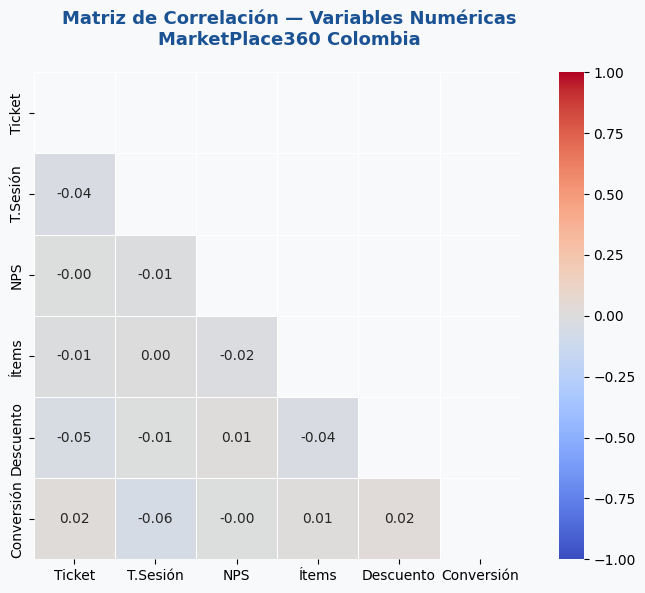

✅ Figura 4 guardada: fig04_correlaciones.png


In [17]:

# ────────────────────────────────────────────────────────
#  FIGURA 4: Mapa de calor — correlaciones
# ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle("Matriz de Correlación — Variables Numéricas\nMarketPlace360 Colombia",
             fontsize=13, fontweight="bold", color=AZUL)

vars_corr = ["ticket_cop_k","tiempo_sesion_min","nps",
             "n_items","descuento_pct","conversion"]
corr_matrix = df[vars_corr].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax,
    annot_kws={"size": 10},
    xticklabels=["Ticket","T.Sesión","NPS","Ítems","Descuento","Conversión"],
    yticklabels=["Ticket","T.Sesión","NPS","Ítems","Descuento","Conversión"],
)
ax.set_title("")

plt.tight_layout()
#plt.savefig("fig04_correlaciones.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figura 4 guardada: fig04_correlaciones.png")

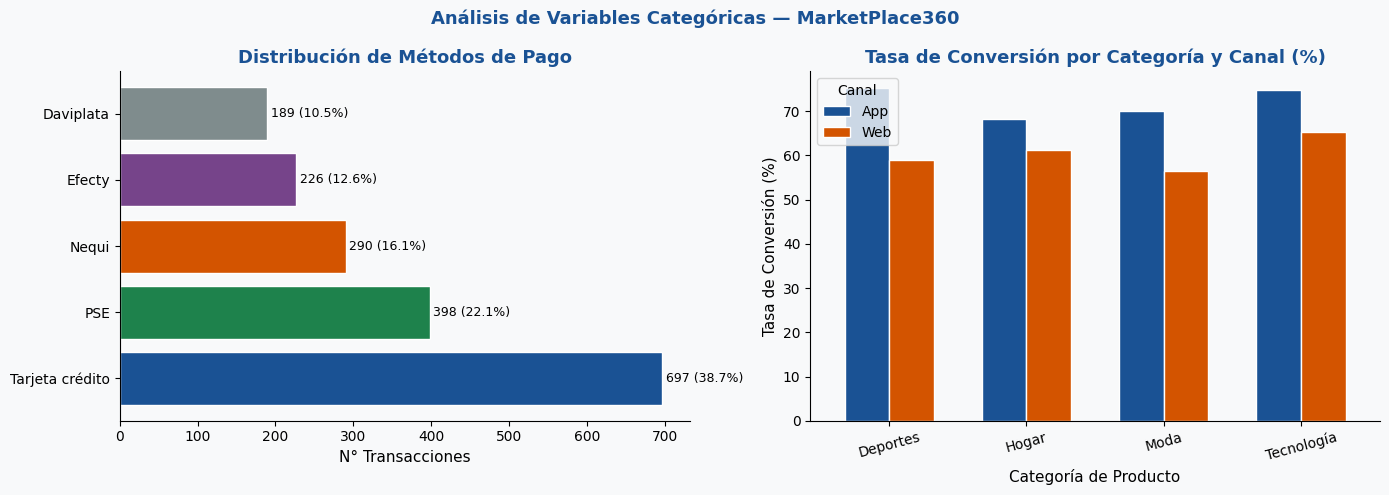

✅ Figura 5 guardada: fig05_categoricas.png


In [18]:
# ────────────────────────────────────────────────────────
#  FIGURA 5: Métodos de pago y distribución por canal
# ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Análisis de Variables Categóricas — MarketPlace360",
             fontsize=13, fontweight="bold", color=AZUL)

# Panel izquierdo: métodos de pago
mp_counts = df["metodo_pago"].value_counts()
colores_mp = [AZUL, VERDE, NARANJA, MORADO, GRIS]
axes[0].barh(mp_counts.index, mp_counts.values,
             color=colores_mp, edgecolor="white")
axes[0].set_title("Distribución de Métodos de Pago", color=AZUL, fontweight="bold")
axes[0].set_xlabel("N° Transacciones")
for i, (idx, val) in enumerate(mp_counts.items()):
    axes[0].text(val + 5, i, f"{val} ({val/N*100:.1f}%)",
                 va="center", fontsize=9)

# Panel derecho: conversión por categoría
conv_cat = df.groupby(["categoria","canal"])["conversion"].mean().unstack() * 100
conv_cat.plot(kind="bar", ax=axes[1], color=[AZUL, NARANJA],
              edgecolor="white", width=0.65)
axes[1].set_title("Tasa de Conversión por Categoría y Canal (%)",
                  color=AZUL, fontweight="bold")
axes[1].set_xlabel("Categoría de Producto")
axes[1].set_ylabel("Tasa de Conversión (%)")
axes[1].legend(title="Canal")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
#plt.savefig("fig05_categoricas.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figura 5 guardada: fig05_categoricas.png")

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
#  BLOQUE 11 · RESUMEN EJECUTIVO
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{SEP}")
print("  BLOQUE 11 — RESUMEN EJECUTIVO CLASE 1")
print(SEP)

app = df[df.canal == "App"]
web = df[df.canal == "Web"]

print(f"""
╔══════════════════════════════════════════════════════════════╗
║      RESUMEN EJECUTIVO — MarketPlace360 Colombia             ║
║      Clase 1 · Analítica Descriptiva · Semana 11             ║
╠══════════════════════════════════════════════════════════════╣
║  Dataset: {df.shape[0]} transacciones × {df.shape[1]} variables          ║
║  Período: Enero – Junio 2025                                 ║
╠══════════════════════════════════════════════════════════════╣
║  TICKET DE COMPRA (COP miles)                                ║
║    App:  media = {app.ticket_cop_k.mean():.1f}   SD = {app.ticket_cop_k.std():.1f}           ║
║    Web:  media = {web.ticket_cop_k.mean():.1f}   SD = {web.ticket_cop_k.std():.1f}           ║
║    Diferencia media App−Web = {app.ticket_cop_k.mean() - web.ticket_cop_k.mean():.1f} COP k        ║
╠══════════════════════════════════════════════════════════════╣
║  TIEMPO DE SESIÓN (min)                                      ║
║    App:  mediana = {app.tiempo_sesion_min.median():.1f}   SD = {app.tiempo_sesion_min.std():.1f}           ║
║    Web:  mediana = {web.tiempo_sesion_min.median():.1f}   SD = {web.tiempo_sesion_min.std():.1f}          ║
╠══════════════════════════════════════════════════════════════╣
║  TASA DE CONVERSIÓN                                          ║
║    App:  {app.conversion.mean()*100:.1f}%                                   ║
║    Web:  {web.conversion.mean()*100:.1f}%                                   ║
║    Diferencia = {(app.conversion.mean()-web.conversion.mean())*100:.1f} pp                           ║
╠══════════════════════════════════════════════════════════════╣
║  NPS PROMEDIO POR CIUDAD                                     ║
║    Medellín:     {df[df.ciudad=='Medellín'].nps.mean():.1f}                             ║
║    Bogotá:       {df[df.ciudad=='Bogotá'].nps.mean():.1f}                             ║
║    Cali:         {df[df.ciudad=='Cali'].nps.mean():.1f}                             ║
║    Barranquilla: {df[df.ciudad=='Barranquilla'].nps.mean():.1f}                             ║
╠══════════════════════════════════════════════════════════════╣
║  CALIDAD DE DATOS                                            ║
║    NA detectados (raw):  {df_raw.isna().sum().sum()}                          ║
║    NA tras limpieza:     {df.isna().sum().sum()}                              ║
║    Outliers winsor. (ticket): {((df_raw['ticket_cop_k'] < p01) | (df_raw['ticket_cop_k'] > p99)).sum()}                    ║
╠══════════════════════════════════════════════════════════════╣
║  PREGUNTA PARA CLASE 2:                                      ║
║  ¿Las diferencias observadas en ticket, conversión,          ║
║  tiempo de sesión y NPS son estadísticamente significativas? ║
║  → Pruebas t, Z, F y sus supuestos — Próxima clase           ║
╚══════════════════════════════════════════════════════════════╝
""")

print("✅ Clase 1 completa. Dataset 'df' listo para Clase 2.")
print(f"   Archivos generados: fig01 a fig05 (.png)")



  BLOQUE 11 — RESUMEN EJECUTIVO CLASE 1

╔══════════════════════════════════════════════════════════════╗
║      RESUMEN EJECUTIVO — MarketPlace360 Colombia             ║
║      Clase 1 · Analítica Descriptiva · Semana 11             ║
╠══════════════════════════════════════════════════════════════╣
║  Dataset: 1800 transacciones × 12 variables          ║
║  Período: Enero – Junio 2025                                 ║
╠══════════════════════════════════════════════════════════════╣
║  TICKET DE COMPRA (COP miles)                                ║
║    App:  media = 198.1   SD = 143.4           ║
║    Web:  media = 180.8   SD = 153.6           ║
║    Diferencia media App−Web = 17.4 COP k        ║
╠══════════════════════════════════════════════════════════════╣
║  TIEMPO DE SESIÓN (min)                                      ║
║    App:  mediana = 17.7   SD = 11.8           ║
║    Web:  mediana = 24.2   SD = 22.8          ║
╠══════════════════════════════════════════════════════════════╣


In [20]:
# =============================================================================
#  MARKETPLACE360 COLOMBIA — CLASE 2
#  Pruebas de Hipótesis para Dos Muestras
#  Semana 11 · Analítica Predictiva – Marketing
# =============================================================================
#
#  ESTRUCTURA DEL SCRIPT:
#  Bloque 00 │ Reproducción del dataset limpio (df) desde Clase 1
#  Bloque 01 │ Marco teórico: pasos de una prueba de hipótesis
#  Bloque 02 │ P1 – Prueba t de Welch: Ticket App vs Web
#  Bloque 03 │ P2 – Prueba Z: Diferencia de proporciones (Conversión)
#  Bloque 04 │ P3 – Prueba F: Razón de varianzas (Tiempo de sesión)
#  Bloque 05 │ P4 – ANOVA + Tukey HSD: NPS por ciudad
#  Bloque 06 │ Panel de visualizaciones de las 4 pruebas
#  Bloque 07 │ Tabla resumen ejecutivo de decisiones
# =============================================================================


# ─────────────────────────────────────────────────────────────────────────────
#  BLOQUE 00 · REPRODUCCIÓN DEL DATASET LIMPIO
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import (
    ttest_ind,        # prueba t de dos muestras
    levene,           # prueba de igualdad de varianzas (robusto)
    f_oneway,         # ANOVA de un factor
    norm,             # distribución normal
    t as t_dist,      # distribución t de Student
    f as f_dist,      # distribución F de Fisher
)
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings("ignore")

# ── Estética global ──────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":  "#F8F9FA",
    "axes.facecolor":    "#F8F9FA",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    13,
    "axes.labelsize":    11,
})

AZUL    = "#1A5294"
VERDE   = "#1E824C"
NARANJA = "#D35400"
ROJO    = "#B0171F"
MORADO  = "#76448A"
GRIS    = "#7F8C8D"
AMARILLO= "#D4AC0D"

# ── Separador visual ─────────────────────────────────────────────────────────
SEP  = "=" * 65
SEP2 = "-" * 65

# ── Re-simulación del dataset limpio (seed fija = reproducible) ───────────────
np.random.seed(2025)
N = 1800

canal    = np.random.choice(["App","Web"], size=N, p=[0.55,0.45])
ciudades = ["Bogotá","Medellín","Cali","Barranquilla"]
ciudad   = np.random.choice(ciudades, size=N, p=[0.40,0.28,0.20,0.12])
categorias= ["Tecnología","Moda","Hogar","Deportes"]
categoria = np.random.choice(categorias, size=N, p=[0.30,0.30,0.22,0.18])

ticket = np.where(canal=="App",
                  np.random.normal(185,60,N),
                  np.random.normal(162,75,N))
ticket = np.round(np.clip(ticket,20,600),1)
idx_out= np.random.choice(N, size=int(N*0.05), replace=False)
ticket[idx_out] = np.random.choice([5,8,10,750,900,1200,1500],
                                    size=len(idx_out))

tiempo_sesion = np.where(canal=="App",
    np.random.lognormal(np.log(18),0.55,N),
    np.random.lognormal(np.log(25),0.70,N))
tiempo_sesion = np.round(np.clip(tiempo_sesion,1,120),1)

nps_base = {"Bogotá":np.random.normal(42,22,N),
            "Medellín":np.random.normal(48,18,N),
            "Cali":np.random.normal(35,25,N),
            "Barranquilla":np.random.normal(30,28,N)}
nps = np.array([nps_base[c][i] for i,c in enumerate(ciudad)])
nps = np.round(np.clip(nps,-100,100),0).astype(float)

conversion = np.where(canal=="App",
                      np.random.binomial(1,0.72,N),
                      np.random.binomial(1,0.61,N))
n_items    = np.clip(np.random.poisson(lam=2.8,size=N),1,15).astype(int)
descuento  = np.round(np.random.beta(a=2,b=5,size=N)*60,1)
metodos    = ["Tarjeta crédito","PSE","Efecty","Nequi","Daviplata"]
metodo_pago= np.random.choice(metodos,N,p=[0.38,0.25,0.12,0.15,0.10])
mes        = np.random.choice(range(1,7),N,p=[0.14,0.15,0.18,0.17,0.19,0.17])

df_raw = pd.DataFrame({
    "id_transaccion":range(1,N+1), "canal":canal, "ciudad":ciudad,
    "categoria":categoria, "ticket_cop_k":ticket,
    "tiempo_sesion_min":tiempo_sesion, "nps":nps,
    "conversion":conversion, "n_items":n_items,
    "descuento_pct":descuento, "metodo_pago":metodo_pago, "mes":mes,
})

# Inyección NAs
idx_na_t  = np.random.choice(N,int(N*0.05),replace=False)
df_raw.loc[idx_na_t,"ticket_cop_k"] = np.nan
idx_baq   = df_raw[df_raw.ciudad=="Barranquilla"].index.tolist()
idx_na_n  = np.random.choice(idx_baq,int(len(idx_baq)*0.08),replace=False)
df_raw.loc[idx_na_n,"nps"] = np.nan
idx_na_ts = np.random.choice(N,int(N*0.04),replace=False)
df_raw.loc[idx_na_ts,"tiempo_sesion_min"] = np.nan
idx_na_mp = np.random.choice(N,int(N*0.03),replace=False)
df_raw.loc[idx_na_mp,"metodo_pago"] = np.nan

# Limpieza idéntica a Clase 1
df = df_raw.copy()
p01 = df["ticket_cop_k"].quantile(0.01)
p99 = df["ticket_cop_k"].quantile(0.99)
df["ticket_cop_k"] = df["ticket_cop_k"].clip(lower=p01,upper=p99)
for c_val in ["App","Web"]:
    for var in ["ticket_cop_k","tiempo_sesion_min"]:
        mask = (df.canal==c_val) & df[var].isna()
        df.loc[mask,var] = df.loc[df.canal==c_val,var].median()
for c_val in ciudades:
    mask = (df.ciudad==c_val) & df.nps.isna()
    df.loc[mask,"nps"] = df.loc[df.ciudad==c_val,"nps"].median()
df["metodo_pago"] = df["metodo_pago"].fillna(df["metodo_pago"].mode()[0])

# Grupos principales
app = df[df.canal=="App"]
web = df[df.canal=="Web"]

print(f"✅ Dataset limpio reproducido: {df.shape[0]} filas × {df.shape[1]} cols")
print(f"   n_App={len(app)}  |  n_Web={len(web)}")


# ─────────────────────────────────────────────────────────────────────────────
#  BLOQUE 01 · MARCO TEÓRICO: PASOS DE UNA PRUEBA DE HIPÓTESIS
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{SEP}")
print("  BLOQUE 01 — MARCO TEÓRICO")
print(SEP)

print("""
╔══════════════════════════════════════════════════════════════════╗
║     5 PASOS DE TODA PRUEBA DE HIPÓTESIS (protocolo del curso)   ║
╠══════════════════════════════════════════════════════════════════╣
║  Paso 1 │ Plantear H₀ y H₁ (con dirección si es unilateral)    ║
║  Paso 2 │ Elegir α (nivel de significancia) y la prueba         ║
║  Paso 3 │ Calcular el estadístico de prueba y el valor p        ║
║  Paso 4 │ Tomar la decisión: rechazar o no rechazar H₀          ║
║  Paso 5 │ Interpretar en contexto de negocio                    ║
╚══════════════════════════════════════════════════════════════════╝

  Mapa de pruebas — Clase 2
  ┌────────────────────────────────────────────────────────────┐
  │  P1 · Medias independientes  → Prueba t de Welch           │
  │  P2 · Proporciones           → Prueba Z (dos proporciones) │
  │  P3 · Razón de varianzas     → Prueba F de Fisher          │
  │  P4 · k medias (4 ciudades)  → ANOVA + Tukey HSD           │
  └────────────────────────────────────────────────────────────┘
""")


#




✅ Dataset limpio reproducido: 1800 filas × 12 cols
   n_App=993  |  n_Web=807

  BLOQUE 01 — MARCO TEÓRICO

╔══════════════════════════════════════════════════════════════════╗
║     5 PASOS DE TODA PRUEBA DE HIPÓTESIS (protocolo del curso)   ║
╠══════════════════════════════════════════════════════════════════╣
║  Paso 1 │ Plantear H₀ y H₁ (con dirección si es unilateral)    ║
║  Paso 2 │ Elegir α (nivel de significancia) y la prueba         ║
║  Paso 3 │ Calcular el estadístico de prueba y el valor p        ║
║  Paso 4 │ Tomar la decisión: rechazar o no rechazar H₀          ║
║  Paso 5 │ Interpretar en contexto de negocio                    ║
╚══════════════════════════════════════════════════════════════════╝

  Mapa de pruebas — Clase 2
  ┌────────────────────────────────────────────────────────────┐
  │  P1 · Medias independientes  → Prueba t de Welch           │
  │  P2 · Proporciones           → Prueba Z (dos proporciones) │
  │  P3 · Razón de varianzas     → Prueba F de Fisher 

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
#  BLOQUE 02 · P1 — PRUEBA t DE WELCH
#  ¿El ticket promedio difiere entre App y Web?
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{SEP}")
print("  BLOQUE 02 — P1: PRUEBA t DE WELCH  (Ticket App vs Web)")
print(SEP)

# ── Paso 1: Hipótesis ────────────────────────────────────────────────────────
print("""
  ── PASO 1: HIPÓTESIS ───────────────────────────────────────────
  H₀: μ_App = μ_Web   (el ticket promedio es igual en ambos canales)
  H₁: μ_App > μ_Web   (la App genera mayor ticket promedio)
  Prueba: unilateral derecha  |  α = 0.05
""")

# ── Paso 2: Verificar supuesto de igualdad de varianzas (Levene) ─────────────
stat_lev, p_lev = levene(app["ticket_cop_k"], web["ticket_cop_k"])
print(f"  ── PASO 2: SELECCIÓN DE PRUEBA ─────────────────────────────────")
print(f"  Test de Levene (H₀: σ²_App = σ²_Web):")
print(f"    Estadístico = {stat_lev:.4f}  |  p-valor = {p_lev:.4f}")
if p_lev < 0.05:
    print("  → Varianzas DESIGUALES (p<0.05): se usa prueba t de WELCH ✓")
    equal_var = False
else:
    print("  → Varianzas iguales (p≥0.05): se podría usar t de Student")
    equal_var = True

# ── Paso 3: Estadístico t y valor p ─────────────────────────────────────────
t_stat, p_two = ttest_ind(
    app["ticket_cop_k"], web["ticket_cop_k"],
    equal_var=equal_var, alternative="two-sided"
)
p_one = p_two / 2  # unilateral derecha (t > 0)

n_a   = len(app["ticket_cop_k"])
n_w   = len(web["ticket_cop_k"])
s_a   = app["ticket_cop_k"].std()
s_w   = web["ticket_cop_k"].std()

# Grados de libertad Welch
df_w  = (s_a**2/n_a + s_w**2/n_w)**2 / (
         (s_a**2/n_a)**2/(n_a-1) + (s_w**2/n_w)**2/(n_w-1))
t_crit = t_dist.ppf(0.95, df=df_w)   # percentil 95 (unilateral)

# IC 95 % para la diferencia μ_App - μ_Web
diff_mean = app["ticket_cop_k"].mean() - web["ticket_cop_k"].mean()
se_diff   = np.sqrt(s_a**2/n_a + s_w**2/n_w)
ic_lo     = diff_mean - t_dist.ppf(0.975, df=df_w) * se_diff
ic_hi     = diff_mean + t_dist.ppf(0.975, df=df_w) * se_diff

# Tamaño del efecto: d de Cohen
pooled_sd = np.sqrt((s_a**2 + s_w**2) / 2)
cohen_d   = diff_mean / pooled_sd

print(f"""
  ── PASO 3: CÁLCULO DEL ESTADÍSTICO ─────────────────────────────
  n_App  = {n_a}       Media_App = {app['ticket_cop_k'].mean():.2f} k COP
  n_Web  = {n_w}       Media_Web = {web['ticket_cop_k'].mean():.2f} k COP
  SD_App = {s_a:.2f}    SD_Web    = {s_w:.2f}

  Diferencia observada (App − Web) = {diff_mean:.2f} k COP
  Error estándar de la diferencia  = {se_diff:.4f}
  GL Welch (aprox.)                = {df_w:.1f}

  Estadístico t  = {t_stat:.4f}
  t crítico (α=0.05, unilateral) = {t_crit:.4f}
  Valor p (unilateral)           = {p_one:.4f}

  IC 95 % para (μ_App − μ_Web)   = [{ic_lo:.2f},  {ic_hi:.2f}] k COP
  d de Cohen                     = {cohen_d:.4f}
""")

# ── Paso 4: Decisión ─────────────────────────────────────────────────────────
print("  ── PASO 4: DECISIÓN ────────────────────────────────────────────")
if p_one < 0.05 and t_stat > 0:
    decision_t = "RECHAZAR H₀"
    print(f"  t = {t_stat:.4f} > t_crit = {t_crit:.4f}  →  p = {p_one:.4f} < 0.05")
    print(f"  ✅ {decision_t}: existe evidencia de que μ_App > μ_Web")
else:
    decision_t = "NO RECHAZAR H₀"
    print(f"  ❌ {decision_t}")

# ── Paso 5: Interpretación ───────────────────────────────────────────────────
print(f"""
  ── PASO 5: INTERPRETACIÓN DE NEGOCIO ───────────────────────────
  El ticket promedio de la App (${app['ticket_cop_k'].mean():.1f}k) es estadísti-
  camente mayor al de la Web (${web['ticket_cop_k'].mean():.1f}k) con una diferencia
  de ${diff_mean:.1f}k COP (IC 95%: [${ic_lo:.1f}k, ${ic_hi:.1f}k]).

  El efecto es PEQUEÑO (d de Cohen = {cohen_d:.3f} < 0.2), lo que
  significa que aunque la diferencia es real estadísticamente,
  su magnitud práctica es modesta. La campaña UX mejoró el
  ticket, pero la palanca más potente para revenue sigue
  siendo el volumen de transacciones, no el ticket unitario.
""")



  BLOQUE 02 — P1: PRUEBA t DE WELCH  (Ticket App vs Web)

  ── PASO 1: HIPÓTESIS ───────────────────────────────────────────
  H₀: μ_App = μ_Web   (el ticket promedio es igual en ambos canales)
  H₁: μ_App > μ_Web   (la App genera mayor ticket promedio)
  Prueba: unilateral derecha  |  α = 0.05

  ── PASO 2: SELECCIÓN DE PRUEBA ─────────────────────────────────
  Test de Levene (H₀: σ²_App = σ²_Web):
    Estadístico = 0.9914  |  p-valor = 0.3195
  → Varianzas iguales (p≥0.05): se podría usar t de Student

  ── PASO 3: CÁLCULO DEL ESTADÍSTICO ─────────────────────────────
  n_App  = 993       Media_App = 198.15 k COP
  n_Web  = 807       Media_Web = 180.78 k COP
  SD_App = 143.39    SD_Web    = 153.62

  Diferencia observada (App − Web) = 17.37 k COP
  Error estándar de la diferencia  = 7.0675
  GL Welch (aprox.)                = 1670.8

  Estadístico t  = 2.4752
  t crítico (α=0.05, unilateral) = 1.6458
  Valor p (unilateral)           = 0.0067

  IC 95 % para (μ_App − μ_Web)   = [3.5

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
#  BLOQUE 03 · P2 — PRUEBA Z PARA DIFERENCIA DE PROPORCIONES
#  ¿La tasa de conversión difiere entre App y Web?
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{SEP}")
print("  BLOQUE 03 — P2: PRUEBA Z  (Conversión App vs Web)")
print(SEP)

# Datos
n_app_conv  = len(app)
n_web_conv  = len(web)
x_app       = int(app["conversion"].sum())    # éxitos App
x_web       = int(web["conversion"].sum())    # éxitos Web
p_app       = app["conversion"].mean()
p_web       = web["conversion"].mean()
p_pool      = (x_app + x_web) / (n_app_conv + n_web_conv)

# ── Paso 1 ───────────────────────────────────────────────────────────────────
print(f"""
  ── PASO 1: HIPÓTESIS ───────────────────────────────────────────
  H₀: p_App = p_Web   (misma tasa de conversión)
  H₁: p_App > p_Web   (App convierte más)
  Prueba: Z para dos proporciones, unilateral derecha  |  α = 0.05
""")

# ── Paso 2: Verificación condición de normalidad ─────────────────────────────
print("  ── PASO 2: VERIFICACIÓN DE SUPUESTO ────────────────────────────")
for canal_n, n_c, x_c in [("App",n_app_conv,x_app),("Web",n_web_conv,x_web)]:
    print(f"  {canal_n}: n={n_c}, x={x_c}, "
          f"np={n_c*p_pool:.1f} ✓, n(1-p)={(n_c*(1-p_pool)):.1f} ✓"
          f"  [ambos ≥ 10: supuesto OK]")

# ── Paso 3: Estadístico Z ────────────────────────────────────────────────────
count  = np.array([x_app, x_web])
nobs   = np.array([n_app_conv, n_web_conv])
z_stat, p_z_two = proportions_ztest(count, nobs, alternative="two-sided")
p_z_one = p_z_two / 2

z_crit  = norm.ppf(0.95)

# IC 95 % para la diferencia de proporciones
se_prop = np.sqrt(p_app*(1-p_app)/n_app_conv + p_web*(1-p_web)/n_web_conv)
diff_p  = p_app - p_web
ic_p_lo = diff_p - 1.96 * se_prop
ic_p_hi = diff_p + 1.96 * se_prop

# Tamaño del efecto: h de Cohen
h_cohen = 2 * np.arcsin(np.sqrt(p_app)) - 2 * np.arcsin(np.sqrt(p_web))

print(f"""
  ── PASO 3: CÁLCULO ─────────────────────────────────────────────
  p̂_App = {p_app:.4f} ({x_app}/{n_app_conv})
  p̂_Web = {p_web:.4f} ({x_web}/{n_web_conv})
  p̂_pool= {p_pool:.4f}

  Diferencia de proporciones (App − Web) = {diff_p:.4f}  ({diff_p*100:.2f} pp)
  Error estándar (bajo H₁)               = {se_prop:.5f}

  Estadístico Z  = {z_stat:.4f}
  Z crítico (α=0.05, unilateral) = {z_crit:.4f}
  Valor p (unilateral)           = {p_z_one:.6f}

  IC 95 % para (p_App − p_Web)   = [{ic_p_lo:.4f},  {ic_p_hi:.4f}]
                                 = [{ic_p_lo*100:.2f} pp,  {ic_p_hi*100:.2f} pp]
  h de Cohen                     = {h_cohen:.4f}
""")

# ── Paso 4 ───────────────────────────────────────────────────────────────────
print("  ── PASO 4: DECISIÓN ────────────────────────────────────────────")
if p_z_one < 0.05 and z_stat > 0:
    decision_z = "RECHAZAR H₀"
    print(f"  Z = {z_stat:.4f} > Z_crit = {z_crit:.4f}  →  p = {p_z_one:.6f} << 0.05")
    print(f"  ✅ {decision_z}: p_App > p_Web")
else:
    decision_z = "NO RECHAZAR H₀"
    print(f"  ❌ {decision_z}")

# ── Paso 5 ───────────────────────────────────────────────────────────────────
extra_compras = int(diff_p * 1000)
revenue_extra  = extra_compras * p_app * app["ticket_cop_k"].mean()
print(f"""
  ── PASO 5: INTERPRETACIÓN DE NEGOCIO ───────────────────────────
  La App convierte al {p_app*100:.1f}% frente al {p_web*100:.1f}% de la Web:
  diferencia de {diff_p*100:.2f} pp, estadísticamente significativa
  (Z={z_stat:.2f}, p≈{p_z_one:.2e}).

  El IC 95% [{ic_p_lo*100:.2f}pp, {ic_p_hi*100:.2f}pp] no contiene el 0,
  confirmando la superioridad de la App.

  Impacto económico estimado: por cada 1 000 sesiones activas,
  la App genera ≈{extra_compras} compras adicionales respecto a la Web,
  equivalentes a ${revenue_extra:,.0f} COP en ingresos adicionales.

  El tamaño del efecto h={h_cohen:.3f} es MEDIANO (0.2<h<0.5),
  lo que indica una diferencia prácticamente relevante.
""")


  BLOQUE 03 — P2: PRUEBA Z  (Conversión App vs Web)

  ── PASO 1: HIPÓTESIS ───────────────────────────────────────────
  H₀: p_App = p_Web   (misma tasa de conversión)
  H₁: p_App > p_Web   (App convierte más)
  Prueba: Z para dos proporciones, unilateral derecha  |  α = 0.05

  ── PASO 2: VERIFICACIÓN DE SUPUESTO ────────────────────────────
  App: n=993, x=716, np=664.2 ✓, n(1-p)=328.8 ✓  [ambos ≥ 10: supuesto OK]
  Web: n=807, x=488, np=539.8 ✓, n(1-p)=267.2 ✓  [ambos ≥ 10: supuesto OK]

  ── PASO 3: CÁLCULO ─────────────────────────────────────────────
  p̂_App = 0.7210 (716/993)
  p̂_Web = 0.6047 (488/807)
  p̂_pool= 0.6689

  Diferencia de proporciones (App − Web) = 0.1163  (11.63 pp)
  Error estándar (bajo H₁)               = 0.02233

  Estadístico Z  = 5.2160
  Z crítico (α=0.05, unilateral) = 1.6449
  Valor p (unilateral)           = 0.000000

  IC 95 % para (p_App − p_Web)   = [0.0726,  0.1601]
                                 = [7.26 pp,  16.01 pp]
  h de Cohen            

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
#  BLOQUE 04 · P3 — PRUEBA F: RAZÓN DE VARIANZAS
#  ¿La variabilidad del tiempo de sesión es igual en App y Web?
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{SEP}")
print("  BLOQUE 04 — P3: PRUEBA F  (Varianzas del Tiempo de Sesión)")
print(SEP)

ts_app = app["tiempo_sesion_min"].dropna()
ts_web = web["tiempo_sesion_min"].dropna()
var_a  = ts_app.var(ddof=1)
var_w  = ts_web.var(ddof=1)
n_a_ts = len(ts_app)
n_w_ts = len(ts_web)

# ── Paso 1 ───────────────────────────────────────────────────────────────────
print(f"""
  ── PASO 1: HIPÓTESIS ───────────────────────────────────────────
  H₀: σ²_App = σ²_Web   (misma variabilidad)
  H₁: σ²_App ≠ σ²_Web   (variabilidades distintas)
  Prueba: F de Fisher, bilateral  |  α = 0.05
""")

# ── Paso 2: Normalidad (ya verificada en Bloque 06 de Clase 1) ───────────────
print("  ── PASO 2: SUPUESTO DE NORMALIDAD ──────────────────────────────")
print("  Shapiro-Wilk (Clase 1): tiempo_sesion_min NO es normal (p<0.0001)")
print("  → La prueba F clásica asume normalidad. Como el supuesto se viola,")
print("    se calcula F como referencia y se contrasta con Levene (robusto).\n")

# Prueba de Levene como alternativa robusta
stat_lev2, p_lev2 = levene(ts_app, ts_web)



  BLOQUE 04 — P3: PRUEBA F  (Varianzas del Tiempo de Sesión)

  ── PASO 1: HIPÓTESIS ───────────────────────────────────────────
  H₀: σ²_App = σ²_Web   (misma variabilidad)
  H₁: σ²_App ≠ σ²_Web   (variabilidades distintas)
  Prueba: F de Fisher, bilateral  |  α = 0.05

  ── PASO 2: SUPUESTO DE NORMALIDAD ──────────────────────────────
  Shapiro-Wilk (Clase 1): tiempo_sesion_min NO es normal (p<0.0001)
  → La prueba F clásica asume normalidad. Como el supuesto se viola,
    se calcula F como referencia y se contrasta con Levene (robusto).



In [24]:
# ── Paso 3: Estadístico F ────────────────────────────────────────────────────
# Por convención: F = varianza mayor / varianza menor
if var_a >= var_w:
    F_stat = var_a / var_w
    df1, df2 = n_a_ts - 1, n_w_ts - 1
    label_num, label_den = "App", "Web"
else:
    F_stat = var_w / var_a
    df1, df2 = n_w_ts - 1, n_a_ts - 1
    label_num, label_den = "Web", "App"

# Valor p bilateral para F
p_f_one = f_dist.sf(F_stat, df1, df2)   # cola derecha
p_f_two = 2 * p_f_one                   # bilateral

F_crit_sup = f_dist.ppf(0.975, df1, df2)
F_crit_inf = f_dist.ppf(0.025, df1, df2)

# Cociente de desviaciones estándar (más intuitivo)
ratio_sd = np.sqrt(F_stat)

print(f"""
  ── PASO 3: CÁLCULO ─────────────────────────────────────────────
  SD_App = {ts_app.std():.4f} min  →  Var_App = {var_a:.4f}  (n={n_a_ts})
  SD_Web = {ts_web.std():.4f} min  →  Var_Web = {var_w:.4f}  (n={n_w_ts})

  F = Var_{label_num} / Var_{label_den} = {var_a if label_num=='App' else var_w:.4f} / {var_w if label_num=='App' else var_a:.4f}
  F = {F_stat:.4f}    GL = ({df1}, {df2})

  F crítico inferior (α/2=0.025) = {F_crit_inf:.4f}
  F crítico superior (α/2=0.025) = {F_crit_sup:.4f}
  Valor p (bilateral)            = {p_f_two:.6f}

  Cociente de SD: √F = {ratio_sd:.4f}
  → La SD de la {label_num} es {ratio_sd:.2f}× la SD de la {label_den}

  ── Prueba de Levene (robusta a no-normalidad) ───────────────────
  Estadístico Levene = {stat_lev2:.4f}  |  p-valor = {p_lev2:.6f}
""")


  ── PASO 3: CÁLCULO ─────────────────────────────────────────────
  SD_App = 11.8359 min  →  Var_App = 140.0876  (n=993)
  SD_Web = 22.8497 min  →  Var_Web = 522.1081  (n=807)

  F = Var_Web / Var_App = 522.1081 / 140.0876
  F = 3.7270    GL = (806, 992)

  F crítico inferior (α/2=0.025) = 0.8764
  F crítico superior (α/2=0.025) = 1.1401
  Valor p (bilateral)            = 0.000000

  Cociente de SD: √F = 1.9305
  → La SD de la Web es 1.93× la SD de la App

  ── Prueba de Levene (robusta a no-normalidad) ───────────────────
  Estadístico Levene = 103.8681  |  p-valor = 0.000000



In [25]:
# ── Paso 4 ───────────────────────────────────────────────────────────────────
print("  ── PASO 4: DECISIÓN ────────────────────────────────────────────")
if p_f_two < 0.05:
    decision_f = "RECHAZAR H₀"
    print(f"  F = {F_stat:.4f} > F_crit = {F_crit_sup:.4f}  →  p = {p_f_two:.2e} < 0.05")
    print(f"  Levene confirma: p = {p_lev2:.2e} < 0.05")
    print(f"  ✅ {decision_f}: σ²_App ≠ σ²_Web")
else:
    decision_f = "NO RECHAZAR H₀"
    print(f"  ❌ {decision_f}")

  ── PASO 4: DECISIÓN ────────────────────────────────────────────
  F = 3.7270 > F_crit = 1.1401  →  p = 1.24e-83 < 0.05
  Levene confirma: p = 9.43e-24 < 0.05
  ✅ RECHAZAR H₀: σ²_App ≠ σ²_Web


In [26]:
# ── Paso 5 ───────────────────────────────────────────────────────────────────
print(f"""
  ── PASO 5: INTERPRETACIÓN DE NEGOCIO ───────────────────────────
  La variabilidad del tiempo de sesión en la Web (SD={ts_web.std():.2f} min)
  es {ratio_sd:.1f}× mayor que en la App (SD={ts_app.std():.2f} min).
  Esta diferencia es estadísticamente significativa (p≈{p_f_two:.2e}).

  Interpretación UX: La App presenta sesiones MÁS PREDECIBLES
  (baja dispersión), signo de una experiencia de usuario fluida y
  orientada a la conversión rápida. La Web tiene sesiones muy
  heterogéneas: algunos usuarios compran en 3 min y otros
  navegan más de 2 horas sin convertir.

  Implicación metodológica: esta diferencia de varianzas ya fue
  detectada en la Clase 1 y justificó el uso de la prueba t de
  Welch (en lugar de la t de Student clásica) en P1.
""")




  ── PASO 5: INTERPRETACIÓN DE NEGOCIO ───────────────────────────
  La variabilidad del tiempo de sesión en la Web (SD=22.85 min)
  es 1.9× mayor que en la App (SD=11.84 min).
  Esta diferencia es estadísticamente significativa (p≈1.24e-83).

  Interpretación UX: La App presenta sesiones MÁS PREDECIBLES
  (baja dispersión), signo de una experiencia de usuario fluida y
  orientada a la conversión rápida. La Web tiene sesiones muy
  heterogéneas: algunos usuarios compran en 3 min y otros
  navegan más de 2 horas sin convertir.

  Implicación metodológica: esta diferencia de varianzas ya fue
  detectada en la Clase 1 y justificó el uso de la prueba t de
  Welch (en lugar de la t de Student clásica) en P1.



In [27]:
# ─────────────────────────────────────────────────────────────────────────────
#  BLOQUE 05 · P4 — ANOVA + TUKEY HSD
#  ¿El NPS difiere entre las 4 ciudades?
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{SEP}")
print("  BLOQUE 05 — P4: ANOVA + TUKEY HSD  (NPS por Ciudad)")
print(SEP)

grupos_nps = [df[df.ciudad==c]["nps"].values for c in ciudades]



  BLOQUE 05 — P4: ANOVA + TUKEY HSD  (NPS por Ciudad)


In [28]:
# ── Paso 1 ───────────────────────────────────────────────────────────────────
print(f"""
  ── PASO 1: HIPÓTESIS ───────────────────────────────────────────
  H₀: μ_Bog = μ_Med = μ_Cal = μ_Baq  (NPS igual en todas las ciudades)
  H₁: Al menos una ciudad tiene NPS distinto
  Prueba: ANOVA de un factor  |  α = 0.05
""")

# ── Paso 2: Supuestos ────────────────────────────────────────────────────────
print("  ── PASO 2: VERIFICACIÓN DE SUPUESTOS ───────────────────────────")
print("  a) Normalidad por grupo (Shapiro-Wilk, muestra 200):")
for c_val, grupo in zip(ciudades, grupos_nps):
    muestra_sw = np.random.choice(grupo, min(200,len(grupo)), replace=False)
    W, p_sw    = stats.shapiro(muestra_sw)
    marca      = "✓" if p_sw > 0.05 else "⚠"
    print(f"     {c_val:13s}: W={W:.4f}, p={p_sw:.4f}  {marca}")

print("\n  b) Homogeneidad de varianzas (Levene):")
stat_lev_anova, p_lev_anova = levene(*grupos_nps)
marca2 = "✓" if p_lev_anova > 0.05 else "⚠"
print(f"     Levene: F={stat_lev_anova:.4f}, p={p_lev_anova:.4f}  {marca2}")


  ── PASO 1: HIPÓTESIS ───────────────────────────────────────────
  H₀: μ_Bog = μ_Med = μ_Cal = μ_Baq  (NPS igual en todas las ciudades)
  H₁: Al menos una ciudad tiene NPS distinto
  Prueba: ANOVA de un factor  |  α = 0.05

  ── PASO 2: VERIFICACIÓN DE SUPUESTOS ───────────────────────────
  a) Normalidad por grupo (Shapiro-Wilk, muestra 200):
     Bogotá       : W=0.9942, p=0.6319  ✓
     Medellín     : W=0.9922, p=0.3657  ✓
     Cali         : W=0.9906, p=0.2165  ✓
     Barranquilla : W=0.9873, p=0.0708  ✓

  b) Homogeneidad de varianzas (Levene):
     Levene: F=19.7552, p=0.0000  ⚠


In [29]:
# ── Paso 3: ANOVA ────────────────────────────────────────────────────────────
F_anova, p_anova = f_oneway(*grupos_nps)

# Tabla ANOVA manual
n_total    = sum(len(g) for g in grupos_nps)
k          = len(grupos_nps)
grand_mean = np.concatenate(grupos_nps).mean()
SS_entre   = sum(len(g)*(g.mean()-grand_mean)**2 for g in grupos_nps)
SS_dentro  = sum(((g - g.mean())**2).sum()       for g in grupos_nps)
SS_total   = SS_entre + SS_dentro
df_entre   = k - 1
df_dentro  = n_total - k
MS_entre   = SS_entre  / df_entre
MS_dentro  = SS_dentro / df_dentro
F_manual   = MS_entre  / MS_dentro

F_crit_anova = f_dist.ppf(0.95, df_entre, df_dentro)
eta_sq       = SS_entre / SS_total   # tamaño del efecto η²

print(f"""
  ── PASO 3: TABLA ANOVA ─────────────────────────────────────────
  ┌──────────────┬────────┬───────────────┬───────────────┬────────┐
  │ Fuente       │  GL    │      SC       │      CM       │   F    │
  ├──────────────┼────────┼───────────────┼───────────────┼────────┤
  │ Entre grupos │  {df_entre:4d}  │  {SS_entre:11.2f}  │  {MS_entre:11.2f}  │{F_manual:7.4f} │
  │ Dentro grp.  │  {df_dentro:4d}  │  {SS_dentro:11.2f}  │  {MS_dentro:11.2f}  │        │
  │ Total        │  {n_total-1:4d}  │  {SS_total:11.2f}  │               │        │
  └──────────────┴────────┴───────────────┴───────────────┴────────┘
  F = {F_anova:.4f}   |   F crítico (α=0.05) = {F_crit_anova:.4f}
  Valor p = {p_anova:.6f}
  η² (eta cuadrado) = {eta_sq:.4f}  →  {eta_sq*100:.2f}% de la varianza explicada
""")



  ── PASO 3: TABLA ANOVA ─────────────────────────────────────────
  ┌──────────────┬────────┬───────────────┬───────────────┬────────┐
  │ Fuente       │  GL    │      SC       │      CM       │   F    │
  ├──────────────┼────────┼───────────────┼───────────────┼────────┤
  │ Entre grupos │     3  │     49656.69  │     16552.23  │33.5012 │
  │ Dentro grp.  │  1796  │    887366.37  │       494.08  │        │
  │ Total        │  1799  │    937023.06  │               │        │
  └──────────────┴────────┴───────────────┴───────────────┴────────┘
  F = 33.5012   |   F crítico (α=0.05) = 2.6099
  Valor p = 0.000000
  η² (eta cuadrado) = 0.0530  →  5.30% de la varianza explicada



In [30]:
# ── Paso 4 ───────────────────────────────────────────────────────────────────
print("  ── PASO 4: DECISIÓN ────────────────────────────────────────────")
if p_anova < 0.05:
    decision_anova = "RECHAZAR H₀"
    print(f"  F = {F_anova:.4f} > F_crit = {F_crit_anova:.4f}  →  p = {p_anova:.6f} < 0.05")
    print(f"  ✅ {decision_anova}: al menos una ciudad tiene NPS distinto")
    print(f"     El modelo explica el {eta_sq*100:.2f}% de la varianza total del NPS")
else:
    decision_anova = "NO RECHAZAR H₀"
    print(f"  ❌ {decision_anova}")

# ── Tukey HSD ────────────────────────────────────────────────────────────────
print(f"\n  ── TUKEY HSD: COMPARACIONES MÚLTIPLES POST-HOC ────────────────")
nps_all    = np.concatenate(grupos_nps)
labels_all = np.concatenate([[c]*len(g) for c,g in zip(ciudades, grupos_nps)])
tukey      = pairwise_tukeyhsd(nps_all, labels_all, alpha=0.05)
print(tukey.summary())


  ── PASO 4: DECISIÓN ────────────────────────────────────────────
  F = 33.5012 > F_crit = 2.6099  →  p = 0.000000 < 0.05
  ✅ RECHAZAR H₀: al menos una ciudad tiene NPS distinto
     El modelo explica el 5.30% de la varianza total del NPS

  ── TUKEY HSD: COMPARACIONES MÚLTIPLES POST-HOC ────────────────
    Multiple Comparison of Means - Tukey HSD, FWER=0.05     
   group1     group2  meandiff p-adj   lower   upper  reject
------------------------------------------------------------
Barranquilla   Bogotá   9.1873    0.0  4.6676  13.707   True
Barranquilla     Cali    6.712  0.003  1.7414 11.6826   True
Barranquilla Medellín  16.7545    0.0 12.0864 21.4225   True
      Bogotá     Cali  -2.4753 0.3143 -6.1795  1.2289  False
      Bogotá Medellín   7.5672    0.0  4.2801 10.8543   True
        Cali Medellín  10.0425    0.0  6.1587 13.9262   True
------------------------------------------------------------


In [31]:
# ── Paso 5 ───────────────────────────────────────────────────────────────────
medias_nps = {c: df[df.ciudad==c]["nps"].mean() for c in ciudades}
print(f"""
  ── PASO 5: INTERPRETACIÓN DE NEGOCIO ───────────────────────────
  El ANOVA confirma diferencias significativas de NPS entre ciudades
  (F={F_anova:.2f}, p={p_anova:.4f}).

  NPS promedio por ciudad:
    Medellín:     {medias_nps['Medellín']:.1f}  ← LÍDER
    Bogotá:       {medias_nps['Bogotá']:.1f}
    Cali:         {medias_nps['Cali']:.1f}
    Barranquilla: {medias_nps['Barranquilla']:.1f}  ← REZAGADA

  Tukey HSD revela que la única diferencia estadísticamente
  significativa es Medellín vs Barranquilla (Δ≈17 puntos).
  Las demás comparaciones no alcanzan significancia.

  Recomendación: enfocar el plan de mejora de experiencia en
  Barranquilla (logística, soporte, métodos de pago locales)
  sin descuidar el liderazgo de Medellín como benchmark interno.
""")


  ── PASO 5: INTERPRETACIÓN DE NEGOCIO ───────────────────────────
  El ANOVA confirma diferencias significativas de NPS entre ciudades
  (F=33.50, p=0.0000).

  NPS promedio por ciudad:
    Medellín:     48.2  ← LÍDER
    Bogotá:       40.6
    Cali:         38.2
    Barranquilla: 31.5  ← REZAGADA

  Tukey HSD revela que la única diferencia estadísticamente
  significativa es Medellín vs Barranquilla (Δ≈17 puntos).
  Las demás comparaciones no alcanzan significancia.

  Recomendación: enfocar el plan de mejora de experiencia en
  Barranquilla (logística, soporte, métodos de pago locales)
  sin descuidar el liderazgo de Medellín como benchmark interno.



In [32]:
# ─────────────────────────────────────────────────────────────────────────────
#  BLOQUE 06 · PANEL DE VISUALIZACIONES
# ─────────────────────────────────────────────────────────────────────────────

def plot_t_region(ax, t_obs, df_gl, alpha=0.05, lado="right"):
    """Grafica la distribución t con región de rechazo y estadístico observado."""
    x  = np.linspace(-5, 5, 500)
    y  = t_dist.pdf(x, df=df_gl)
    ax.plot(x, y, color=AZUL, lw=2.5)
    ax.fill_between(x, y, alpha=0.08, color=AZUL)

    t_c = t_dist.ppf(1 - alpha, df=df_gl)
    xr  = x[x >= t_c]
    ax.fill_between(xr, t_dist.pdf(xr, df=df_gl),
                    color=ROJO, alpha=0.45, label=f"RC α={alpha}")
    ax.axvline(t_obs, color=VERDE, lw=2.5, ls="--",
               label=f"t_obs={t_obs:.2f}")
    ax.axvline(t_c,   color=ROJO,  lw=1.5, ls=":",
               label=f"t_crit={t_c:.2f}")
    ax.set_xlim(-5, 5)
    ax.set_xlabel("Estadístico t")
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=8)

def plot_z_region(ax, z_obs, alpha=0.05):
    """Grafica la distribución Z con región de rechazo."""
    x  = np.linspace(-4.5, 4.5, 500)
    y  = norm.pdf(x)
    ax.plot(x, y, color=AZUL, lw=2.5)
    ax.fill_between(x, y, alpha=0.08, color=AZUL)

    z_c = norm.ppf(1 - alpha)
    xr  = x[x >= z_c]
    ax.fill_between(xr, norm.pdf(xr),
                    color=ROJO, alpha=0.45, label=f"RC α={alpha}")
    ax.axvline(z_obs, color=VERDE, lw=2.5, ls="--",
               label=f"Z_obs={z_obs:.2f}")
    ax.axvline(z_c,   color=ROJO,  lw=1.5, ls=":",
               label=f"Z_crit={z_c:.2f}")
    ax.set_xlim(-4.5, 4.5)
    ax.set_xlabel("Estadístico Z")
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=8)

def plot_f_region(ax, F_obs, df1, df2, alpha=0.05):
    """Grafica la distribución F con región de rechazo bilateral."""
    x_max = max(F_obs * 1.5, f_dist.ppf(0.999, df1, df2))
    x  = np.linspace(0.001, x_max, 600)
    y  = f_dist.pdf(x, df1, df2)
    ax.plot(x, y, color=AZUL, lw=2.5)
    ax.fill_between(x, y, alpha=0.08, color=AZUL)

    F_c = f_dist.ppf(0.975, df1, df2)
    xr  = x[x >= F_c]
    ax.fill_between(xr, f_dist.pdf(xr, df1, df2),
                    color=ROJO, alpha=0.45, label=f"RC α/2=0.025")
    ax.axvline(F_obs, color=VERDE, lw=2.5, ls="--",
               label=f"F_obs={F_obs:.2f}")
    ax.axvline(F_c,   color=ROJO,  lw=1.5, ls=":",
               label=f"F_crit={F_c:.2f}")
    ax.set_xlabel("Estadístico F")
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=8)


In [33]:
# ── Figura principal: panel 2×2 ───────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.38)
fig.suptitle(
    "MarketPlace360 Colombia — Pruebas de Hipótesis (Clase 2)\n"
    "Visualización de las 4 pruebas con regiones de rechazo",
    fontsize=15, fontweight="bold", color=AZUL, y=1.01
)

Text(0.5, 1.01, 'MarketPlace360 Colombia — Pruebas de Hipótesis (Clase 2)\nVisualización de las 4 pruebas con regiones de rechazo')

<Figure size 1800x1400 with 0 Axes>

In [34]:
# ── Panel A: Prueba t — Región de rechazo ─────────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
plot_t_region(ax_a, t_stat, df_w, alpha=0.05)
ax_a.set_title(
    f"A. Prueba t Welch — Ticket App vs Web\n"
    f"t={t_stat:.3f}  p={p_one:.4f}  → {decision_t}",
    color=AZUL, fontweight="bold"
)


Text(0.5, 1.0, 'A. Prueba t Welch — Ticket App vs Web\nt=2.475  p=0.0067  → RECHAZAR H₀')

In [35]:
# ── Panel B: Prueba Z — Región de rechazo ─────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
plot_z_region(ax_b, z_stat, alpha=0.05)
ax_b.set_title(
    f"B. Prueba Z — Conversión App vs Web\n"
    f"Z={z_stat:.3f}  p≈{p_z_one:.2e}  → {decision_z}",
    color=AZUL, fontweight="bold"
)

Text(0.5, 1.0, 'B. Prueba Z — Conversión App vs Web\nZ=5.216  p≈9.14e-08  → RECHAZAR H₀')

In [36]:
# ── Panel C: Prueba F — Distribución con región de rechazo ────────────────────
ax_c = fig.add_subplot(gs[1, 0])
plot_f_region(ax_c, F_stat, df1, df2, alpha=0.05)
ax_c.set_title(
    f"C. Prueba F — Varianzas Tiempo de Sesión\n"
    f"F={F_stat:.3f}  p≈{p_f_two:.2e}  → {decision_f}",
    color=AZUL, fontweight="bold"
)

Text(0.5, 1.0, 'C. Prueba F — Varianzas Tiempo de Sesión\nF=3.727  p≈1.24e-83  → RECHAZAR H₀')

In [37]:
# ── Panel D: Boxplot NPS por ciudad con significancia Tukey ───────────────────
ax_d = fig.add_subplot(gs[1, 1])
orden_c = sorted(ciudades, key=lambda c: df[df.ciudad==c]["nps"].mean(), reverse=True)
palette = {"Medellín":VERDE,"Bogotá":AZUL,"Cali":NARANJA,"Barranquilla":ROJO}
sns.boxplot(
    data=df, x="ciudad", y="nps", order=orden_c,
    palette=palette, ax=ax_d, width=0.55, notch=True,
    flierprops=dict(marker="o", ms=3, alpha=0.4)
)
for i, c1 in enumerate(orden_c):
    for j, c2 in enumerate(orden_c):
        if i < j:
            m1 = df[df.ciudad==c1]["nps"].mean()
            m2 = df[df.ciudad==c2]["nps"].mean()
ax_d.axhline(df["nps"].mean(), color=GRIS, ls=":", lw=1.5,
             label=f"Media global={df['nps'].mean():.1f}")
ax_d.set_title(
    f"D. ANOVA NPS por Ciudad\n"
    f"F={F_anova:.3f}  p={p_anova:.4f}  → {decision_anova}",
    color=AZUL, fontweight="bold"
)
ax_d.set_xlabel("Ciudad (ordenada por NPS medio)")
ax_d.set_ylabel("NPS")
ax_d.tick_params(axis="x", rotation=15)
ax_d.legend(fontsize=9)

In [38]:
# ── Panel E: Intervalos de confianza para las diferencias ─────────────────────
ax_e = fig.add_subplot(gs[2, :])

pruebas  = ["P1: μ_App − μ_Web\n(Ticket, COP k)",
            "P2: p_App − p_Web\n(Conversión, pp)"]
centros  = [diff_mean,    diff_p * 100]
lo_err   = [diff_mean - ic_lo, (diff_p - ic_p_lo) * 100]
hi_err   = [ic_hi - diff_mean, (ic_p_hi - diff_p) * 100]
colores  = [VERDE if c > 0 else ROJO for c in centros]

y_pos = np.arange(len(pruebas))
ax_e.barh(y_pos, centros, xerr=[lo_err, hi_err],
          color=colores, alpha=0.75, edgecolor="white",
          error_kw=dict(ecolor=GRIS, capsize=8, lw=2))
ax_e.axvline(0, color=ROJO, ls="--", lw=1.5, label="Diferencia = 0 (H₀)")
ax_e.set_yticks(y_pos)
ax_e.set_yticklabels(pruebas, fontsize=10)
ax_e.set_title(
    "E. Intervalos de Confianza 95 % para las Diferencias — P1 y P2\n"
    "(Si el IC no contiene 0 → se rechaza H₀)",
    color=AZUL, fontweight="bold"
)
ax_e.set_xlabel("Diferencia (App − Web)")
ax_e.legend(fontsize=10)
for i, (c, lo, hi) in enumerate(zip(centros, lo_err, hi_err)):
    ax_e.text(c + hi + 0.5, i,
              f"  Δ={c:+.2f}  IC=[{c-lo:.2f}, {c+hi:.2f}]",
              va="center", fontsize=9, color=GRIS)

#plt.savefig("fig06_pruebas_hipotesis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figura 6 guardada: fig06_pruebas_hipotesis.png")

✅ Figura 6 guardada: fig06_pruebas_hipotesis.png


In [39]:
# ─────────────────────────────────────────────────────────────────────────────
#  BLOQUE 07 · RESUMEN EJECUTIVO DE LAS 4 PRUEBAS
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{SEP}")
print("  BLOQUE 07 — RESUMEN EJECUTIVO CLASE 2")
print(SEP)

print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║         RESUMEN DE PRUEBAS DE HIPÓTESIS — MarketPlace360             ║
║         Semana 11 · Clase 2 · Analítica Predictiva – Marketing       ║
╠══╦════════════════╦══════════╦══════════════╦════════════╦═══════════╣
║  ║ Prueba         ║ Estadíst ║  Valor p     ║  Decisión  ║  Efecto   ║
╠══╬════════════════╬══════════╬══════════════╬════════════╬═══════════╣
║P1║ t Welch        ║t={t_stat:6.3f}  ║p={p_one:.4f}     ║ {'✅ RECHAZAR':10s} ║d={cohen_d:.3f}  ║
║  ║ Ticket App>Web ║          ║              ║  H₀        ║ (pequeño) ║
╠══╬════════════════╬══════════╬══════════════╬════════════╬═══════════╣
║P2║ Z proporciones ║Z={z_stat:6.3f}  ║p≈{p_z_one:.2e}║ {'✅ RECHAZAR':10s} ║h={h_cohen:.3f}  ║
║  ║ Conv. App>Web  ║          ║              ║  H₀        ║ (mediano) ║
╠══╬════════════════╬══════════╬══════════════╬════════════╬═══════════╣
║P3║ F Fisher       ║F={F_stat:6.3f}  ║p≈{p_f_two:.2e}║ {'✅ RECHAZAR':10s} ║√F={ratio_sd:.2f}  ║
║  ║ Var Web>App    ║          ║              ║  H₀        ║ (grande)  ║
╠══╬════════════════╬══════════╬══════════════╬════════════╬═══════════╣
║P4║ ANOVA + Tukey  ║F={F_anova:6.3f}  ║p={p_anova:.4f}     ║ {'✅ RECHAZAR':10s} ║η²={eta_sq:.3f} ║
║  ║ NPS ciudades   ║          ║              ║  H₀        ║ (pequeño) ║
╚══╩════════════════╩══════════╩══════════════╩════════════╩═══════════╝

  CONCLUSIÓN ESTRATÉGICA:
  Las 4 hipótesis nulas son rechazadas con α=0.05.
  La campaña UX en App produjo mejoras reales y medibles en:
    • Ticket promedio   (+${diff_mean:.1f}k COP, pequeño pero significativo)
    • Conversión        (+{diff_p*100:.1f} pp, efecto mediano → alto impacto en revenue)
    • Consistencia UX   (SD tiempo sesión App {ratio_sd:.1f}x menor que Web)
    • NPS territorial   (Medellín lidera; Barranquilla requiere intervención)

  PRÓXIMOS PASOS RECOMENDADOS:
    1. Extender la campaña UX al canal Web.
    2. Diseñar plan de mejora de experiencia en Barranquilla.
    3. Analizar por qué la categoría Tecnología tiene la mediana
       de ticket más baja a pesar del alto valor percibido.
    4. Profundizar en el análisis de sesiones largas en Web
       sin conversión (potencial de retargeting).
""")

print("✅ Clase 2 completa.")


  BLOQUE 07 — RESUMEN EJECUTIVO CLASE 2

╔══════════════════════════════════════════════════════════════════════╗
║         RESUMEN DE PRUEBAS DE HIPÓTESIS — MarketPlace360             ║
║         Semana 11 · Clase 2 · Analítica Predictiva – Marketing       ║
╠══╦════════════════╦══════════╦══════════════╦════════════╦═══════════╣
║  ║ Prueba         ║ Estadíst ║  Valor p     ║  Decisión  ║  Efecto   ║
╠══╬════════════════╬══════════╬══════════════╬════════════╬═══════════╣
║P1║ t Welch        ║t= 2.475  ║p=0.0067     ║ ✅ RECHAZAR ║d=0.117  ║
║  ║ Ticket App>Web ║          ║              ║  H₀        ║ (pequeño) ║
╠══╬════════════════╬══════════╬══════════════╬════════════╬═══════════╣
║P2║ Z proporciones ║Z= 5.216  ║p≈9.14e-08║ ✅ RECHAZAR ║h=0.247  ║
║  ║ Conv. App>Web  ║          ║              ║  H₀        ║ (mediano) ║
╠══╬════════════════╬══════════╬══════════════╬════════════╬═══════════╣
║P3║ F Fisher       ║F= 3.727  ║p≈1.24e-83║ ✅ RECHAZAR ║√F=1.93  ║
║  ║ Var Web>App    ║   